# Analitica De Datos Proyecto Final - ETL

En este proyecto se desarrollará un proceso ETL (Extracción, Transformación y Carga) sobre el conjunto de datos Building_Energy_Efficiency.csv, que contiene parámetros de diseño y características geométricas de edificios. El propósito es explorar, limpiar y transformar la información, tratando valores faltantes, datos atípicos, variables redundantes e irrelevantes, con el fin de obtener un conjunto de datos confiable y estructurado que permita aplicar modelos de Machine Learning para predecir la demanda energética de calefacción (Heating_Load) y refrigeración (Cooling_Load) de los edificios.

El conjunto de datos está compuesto por diferentes variables relacionadas con las características físicas y estructurales de los edificios. Entre ellas se encuentran medidas como la superficie total, el área de las paredes y del techo, la altura, la compacidad relativa y aspectos relacionados con el acristalamiento, además de variables que representan la orientación y distribución de las ventanas. También incluye información adicional como identificadores y atributos descriptivos de los registros. Algunas variables presentan características particulares que deben considerarse durante el análisis, como columnas con alta cantidad de valores únicos, variables con poca variación y campos que contienen información duplicada. Asimismo, las variables asociadas a la demanda energética permiten analizar el comportamiento térmico de los edificios y su relación con los diferentes parámetros de diseño.


## Paso 1. Carga y exploración inicial de los datos

En este primer paso se realiza la carga del conjunto de datos Building_Energy_Efficiency.csv utilizando la biblioteca pandas. Se establece la ruta donde se encuentra almacenado el archivo y se utiliza la función read_csv() para importar la información y almacenarla en un DataFrame denominado df.

Se especifica la codificación utf-8 para facilitar la correcta lectura de los caracteres presentes en el archivo. Posteriormente, mediante head() se visualizan los primeros registros del conjunto de datos, con el propósito de comprobar que la información fue cargada correctamente y obtener una primera aproximación a las variables que lo componen.

In [21]:
import pandas as pd

file_path = r"C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\datasets\Building_Energy_Efficiency.csv"

df = pd.read_csv(file_path, encoding='utf-8')

print(df.head()) 
print(df.info())
print(df.describe())

   RecordID        FullName         Phone ZodiacSign FavoriteColor      Hobby  \
0  REC00001  Charles Garcia  3.463801e+09      Aries         Green     Gaming   
1  REC00002     Maria Davis  3.019892e+09     Taurus           Red     Gaming   
2  REC00003    Maria Garcia  3.713299e+09     Pisces         White     Hiking   
3  REC00004    Carmen Brown  3.356458e+09  Capricorn         Green    Dancing   
4  REC00005   Carmen Taylor  3.441862e+09     Pisces        Orange  Gardening   

   Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  Overall_Height  \
0                  0.74    665.429402  328.616746  138.193576             3.5   
1                  0.85    786.761968  419.578324  194.659517             7.0   
2                  0.94    627.172679  378.012514  109.969135             3.5   
3                  0.83    719.556163  398.526872  118.328080             7.0   
4                  0.82    558.936051  309.682859  143.892194             3.5   

   Orientation  Glazing_Ar

| Variable                    | Traducción                               |
| --------------------------- | ---------------------------------------- |
| `RecordID`                  | ID del registro                          |
| `FullName`                  | Nombre completo                          |
| `Phone`                     | Teléfono                                 |
| `ZodiacSign`                | Signo zodiacal                           |
| `FavoriteColor`             | Color favorito                           |
| `Hobby`                     | Pasatiempo                               |
| `Relative_Compactness`      | Compactación relativa                    |
| `Surface_Area`              | Área de superficie                       |
| `Wall_Area`                 | Área de paredes                          |
| `Roof_Area`                 | Área del techo                           |
| `Overall_Height`            | Altura total                             |
| `Orientation`               | Orientación                              |
| `Glazing_Area`              | Área de acristalamiento                  |
| `Glazing_Area_Distribution` | Distribución del área de acristalamiento |
| `Surface_Area_m2`           | Área de superficie en m²                 |
| `BuildingCode`              | Código del edificio                      |
| `Country`                   | País                                     |
| `Heating_Load`              | Carga de calefacción                     |
| `Cooling_Load`              | Carga de refrigeración                   |
| `Total_Load`                | Carga total                              |


La carga del conjunto de datos se realizó correctamente. El DataFrame contiene 1.000 registros y 20 variables, lo que permite contar con una cantidad adecuada de observaciones para realizar posteriormente el proceso de análisis y preparación de los datos.

A partir de la información obtenida mediante head() se observa que el conjunto de datos contiene variables de diferentes tipos. Algunas corresponden a características personales o identificadores, como RecordID, FullName, Phone, ZodiacSign, FavoriteColor y Hobby; mientras que otras representan características físicas y estructurales de los edificios, como Relative_Compactness, Surface_Area, Wall_Area, Roof_Area, Overall_Height, Orientation y Glazing_Area.

También se identifican las variables objetivo relacionadas con el consumo energético: Heating_Load, Cooling_Load y Total_Load. Estas variables serán de especial interés en las etapas posteriores del análisis.

Un aspecto importante identificado en esta primera exploración es la presencia de valores faltantes. Las variables Relative_Compactness, Wall_Area y Glazing_Area cuentan con 900 valores no nulos, mientras que Surface_Area presenta 908 valores no nulos. Las demás variables contienen los 1.000 registros completos. Esto indica que será necesario realizar posteriormente un tratamiento específico de los valores faltantes.

Finalmente, se observa que el conjunto contiene 11 variables de tipo float64, 2 de tipo int64 y 7 de tipo object, por lo que en las siguientes etapas será necesario analizar tanto las variables numéricas como las categóricas para determinar cuáles son relevantes para el proceso de modelado.

## Paso 2. Selección de variables relevantes

En este segundo paso se realiza una selección de las variables que presentan mayor relevancia para el análisis de la eficiencia energética de los edificios. Debido a que el objetivo del proyecto es desarrollar modelos para analizar y predecir la demanda energética, se conservan las variables relacionadas directamente con las características físicas y de diseño de las edificaciones, junto con las variables que representan las demandas energéticas que serán utilizadas como variables objetivo.

Las variables predictoras seleccionadas son Relative_Compactness, Surface_Area, Wall_Area, Roof_Area, Overall_Height, Orientation, Glazing_Area y Glazing_Area_Distribution. Estas variables representan aspectos geométricos y estructurales del edificio que pueden influir en su comportamiento térmico.

Como variables objetivo se conservan Heating_Load, correspondiente a la demanda de calefacción, y Cooling_Load, correspondiente a la demanda de refrigeración. Estas variables serán utilizadas posteriormente en los modelos de regresión para evaluar la capacidad de las características del edificio para explicar y predecir sus demandas energéticas.

Por otro lado, se eliminan las variables RecordID, FullName, Phone, ZodiacSign, FavoriteColor, Hobby, BuildingCode y Country, debido a que corresponden principalmente a identificadores, información personal o características descriptivas que no aportan información relevante para el objetivo del análisis. También se elimina Surface_Area_m2, debido a que contiene información duplicada respecto a Surface_Area`.

Finalmente, se elimina Total_Load, ya que corresponde a la suma de Heating_Load y Cooling_Load. Al ser una variable derivada directamente de las variables objetivo, su utilización como variable predictora podría generar fuga de información (data leakage) y afectar la validez de los modelos de regresión.

De esta manera, el conjunto de datos queda conformado por 8 variables predictoras y 2 variables objetivo, proporcionando una estructura más limpia y enfocada en el análisis de la eficiencia energética de los edificios.

### Variables a eliminar

| Variable          | Traducción                 |
| ----------------- | -------------------------- |
| `RecordID`        | Identificador del registro |
| `FullName`        | Nombre completo            |
| `Phone`           | Teléfono                   |
| `ZodiacSign`      | Signo zodiacal             |
| `FavoriteColor`   | Color favorito             |
| `Hobby`           | Pasatiempo                 |
| `Surface_Area_m2` | Área de superficie en m²   |
| `BuildingCode`    | Código del edificio        |
| `Country`         | País                       |
| `Total_Load`      | Demanda energética total   |



### Variables a conservar

| Variable                    | Traducción                       |
| --------------------------- | -------------------------------- |
| `Relative_Compactness`      | Compacidad relativa              |
| `Surface_Area`              | Área de superficie               |
| `Wall_Area`                 | Área de paredes                  |
| `Roof_Area`                 | Área del techo                   |
| `Overall_Height`            | Altura total                     |
| `Orientation`               | Orientación                      |
| `Glazing_Area`              | Área de acristalamiento          |
| `Glazing_Area_Distribution` | Distribución del acristalamiento |
| `Heating_Load`              | Demanda de calefacción           |
| `Cooling_Load`              | Demanda de refrigeración         |



In [22]:
# Variables que no se utilizarán en el análisis
variables_eliminar = [
    'RecordID',
    'FullName',
    'Phone',
    'ZodiacSign',
    'FavoriteColor',
    'Hobby',
    'Surface_Area_m2',
    'BuildingCode',
    'Country',
    'Total_Load'
]

df = df.drop(columns=variables_eliminar)


print("Variables después de la selección:")
print(df.columns.tolist())
print(df.info())

Variables después de la selección:
['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       900 non-null    float64
 1   Surface_Area               908 non-null    float64
 2   Wall_Area                  900 non-null    float64
 3   Roof_Area                  1000 non-null   float64
 4   Overall_Height             1000 non-null   float64
 5   Orientation                1000 non-null   int64  
 6   Glazing_Area               900 non-null    float64
 7   Glazing_Area_Distribution  1000 non-null   int64  
 8   Heating_Load               1000 non-null   float64
 9   Cooling_Load               1000 non-null   float64
dtypes: fl

La selección de variables se realizó correctamente. El conjunto de datos pasó de 20 a 10 variables, eliminando aquellas que no aportan información relevante para el objetivo de predicción energética, así como variables redundantes o derivadas.

Las 10 variables restantes son de tipo numérico, con 8 variables float64 y 2 variables int64. Esto representa una ventaja para las etapas posteriores de análisis y modelado de regresión, ya que no quedan variables de tipo texto que requieran una transformación categórica.

Se mantienen 8 variables predictoras relacionadas con las características físicas y de diseño de los edificios, mientras que Heating_Load y Cooling_Load se conservan como variables objetivo para los modelos de regresión.

También se confirma la existencia de valores faltantes en cuatro variables predictoras:

Relative_Compactness: 100 valores faltantes.
Surface_Area: 92 valores faltantes.
Wall_Area: 100 valores faltantes.
Glazing_Area: 100 valores faltantes.

Las demás variables presentan los 1.000 registros completos.

## Paso 3. Análisis exploratorio de los datos

En este tercer paso se realiza un Análisis Exploratorio de Datos utilizando la biblioteca ydata_profiling. Esta herramienta permite generar automáticamente un informe detallado sobre la estructura y calidad del conjunto de datos.

El informe permite identificar características importantes como estadísticas descriptivas, distribución de las variables, valores faltantes, valores únicos, posibles valores atípicos, correlaciones y relaciones entre las diferentes variables.

Para ello, se utiliza ProfileReport() sobre el DataFrame df y se configura el parámetro explorative=True con el fin de obtener un análisis más completo. El informe generado se muestra directamente dentro de Jupyter Notebook mediante display().

Este análisis permite obtener una visión general del estado de los datos y detectar posibles problemas que deberán ser tratados en las siguientes etapas del proceso ETL, especialmente aquellos relacionados con valores faltantes, variables altamente correlacionadas, datos atípicos y distribución de las variables.

In [23]:
from ydata_profiling import ProfileReport
from IPython.display import display


perfil = ProfileReport(
    df,
    title="Informe de Análisis Exploratorio de Datos",
    explorative=True
)

display(perfil)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 183.17it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

El informe de análisis exploratorio generado con ydata_profiling permite identificar varios aspectos importantes sobre la calidad y las relaciones existentes en el conjunto de datos.

En primer lugar, se observa una alta correlación entre Heating_Load y Cooling_Load. Esto indica que las demandas de calefacción y refrigeración presentan un comportamiento relacionado. Sin embargo, esta correlación no implica que debamos eliminar ninguna de las dos variables, ya que ambas son variables objetivo del proyecto.

También se identifica una alta correlación entre Overall_Height y Cooling_Load, lo que sugiere que la altura total del edificio podría tener una relación importante con la demanda de refrigeración. Esta variable debe conservarse para las etapas posteriores de modelado.

Uno de los principales problemas detectados corresponde a los valores faltantes. Se encuentran datos ausentes en cuatro variables:

Relative_Compactness: 100 valores (10%)
Surface_Area: 92 valores (9,2%)
Wall_Area: 100 valores (10%)
Glazing_Area: 100 valores (10%)

Estos valores faltantes deberán ser tratados antes de construir los modelos de regresión.

El informe también señala que Roof_Area y Cooling_Load presentan valores únicos. En este contexto, esto no significa necesariamente que exista un problema. Una variable puede tener muchos valores diferentes y seguir siendo completamente válida. En particular, Cooling_Load es una variable numérica continua, por lo que es normal que presente una gran cantidad de valores únicos.

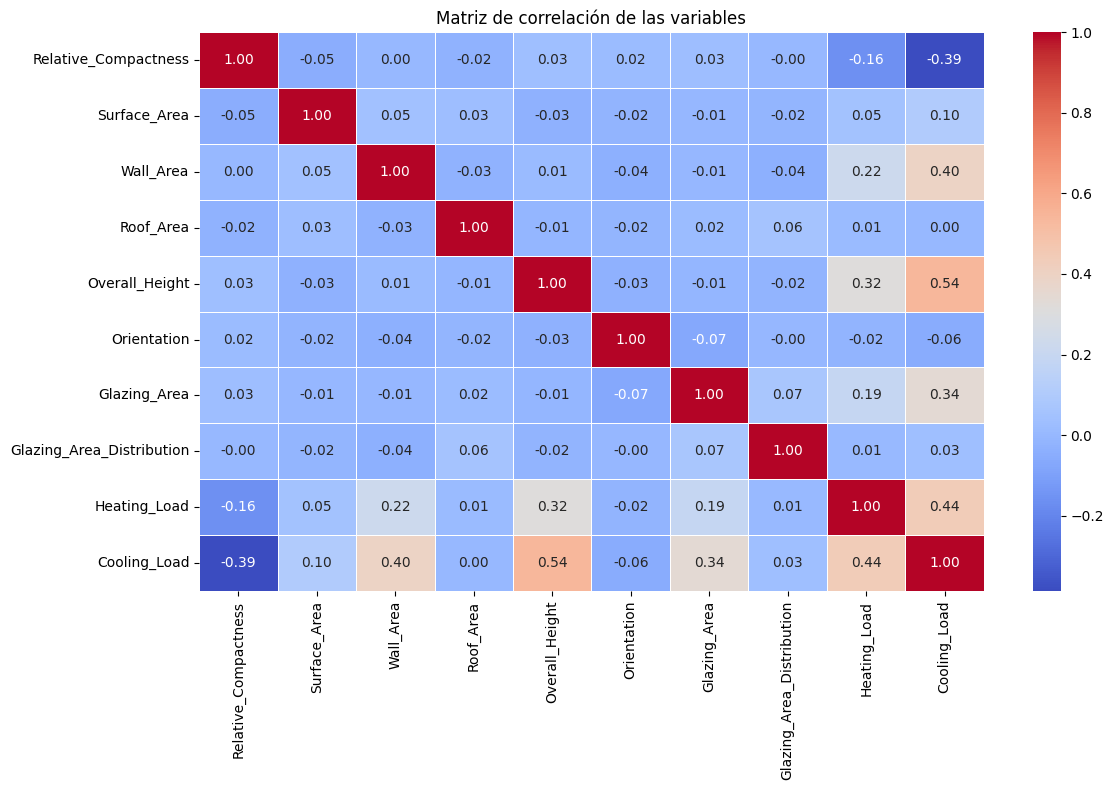

Tabla de correlación:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
Relative_Compactness,1.00,-0.05,0.00,-0.02,0.03,0.02,0.03,-0.00,-0.16,-0.39
Surface_Area,-0.05,1.00,0.05,0.03,-0.03,-0.02,-0.01,-0.02,0.05,0.10
Wall_Area,0.00,0.05,1.00,-0.03,0.01,-0.04,-0.01,-0.04,0.22,0.40
Roof_Area,-0.02,0.03,-0.03,1.00,-0.01,-0.02,0.02,0.06,0.01,0.00
Overall_Height,0.03,-0.03,0.01,-0.01,1.00,-0.03,-0.01,-0.02,0.32,0.54
Orientation,0.02,-0.02,-0.04,-0.02,-0.03,1.00,-0.07,-0.00,-0.02,-0.06
Glazing_Area,0.03,-0.01,-0.01,0.02,-0.01,-0.07,1.00,0.07,0.19,0.34
Glazing_Area_Distribution,-0.00,-0.02,-0.04,0.06,-0.02,-0.00,0.07,1.00,0.01,0.03
Heating_Load,-0.16,0.05,0.22,0.01,0.32,-0.02,0.19,0.01,1.00,0.44
Cooling_Load,-0.39,0.10,0.40,0.00,0.54,-0.06,0.34,0.03,0.44,1.00


In [24]:
%matplotlib inline



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include='number')

# Calcular matriz de correlación
correlacion = variables_numericas.corr()

# =========================
# GRÁFICA DE CORRELACIÓN
# =========================

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de correlación de las variables')
plt.tight_layout()
plt.show()

# =========================
# TABLA DE CORRELACIÓN
# =========================

print("Tabla de correlación:")

display(correlacion.round(2))

La matriz de correlación permite identificar la relación entre las variables seleccionadas y determinar cuáles presentan mayor asociación con las variables objetivo: Heating_Load y Cooling_Load.

1. Correlación con Heating_Load

Las relaciones más importantes son:

Overall_Height: 0.32, correlación positiva moderada-baja.
Wall_Area: 0.22, correlación positiva baja.
Glazing_Area: 0.19, correlación positiva baja.
Relative_Compactness: -0.16, correlación negativa baja.

Las demás variables presentan correlaciones cercanas a cero, por lo que su relación lineal individual con la demanda de calefacción es débil.

2. Correlación con Cooling_Load

Se observan relaciones más marcadas:

Overall_Height: 0.54, siendo la correlación más fuerte con la demanda de refrigeración.
Wall_Area: 0.40, correlación positiva moderada.
Relative_Compactness: -0.39, correlación negativa moderada.
Glazing_Area: 0.34, correlación positiva moderada-baja.

Esto indica que, de manera individual, estas variables tienen una mayor relación lineal con la demanda de refrigeración.

3. Correlación entre las variables predictoras

Las correlaciones entre las variables predictoras son, en general, muy bajas, cercanas a cero. Esto es favorable porque no se observa una fuerte relación lineal entre los predictores que pudiera indicar un problema evidente de multicolinealidad.

4. Relación entre las variables objetivo

Heating_Load y Cooling_Load presentan una correlación de 0.44, lo que indica una relación positiva moderada: los edificios con mayor demanda de calefacción tienden, en cierta medida, a presentar también mayor demanda de refrigeración.

## Paso 5. Tratamiento de valores faltantes y valores atípicos

En esta etapa se realizará el tratamiento de los problemas de calidad identificados en el análisis anterior. Los valores faltantes de Relative_Compactness, Surface_Area, Wall_Area y Glazing_Area serán imputados mediante el método KNN (K-Nearest Neighbors), utilizando la similitud entre las observaciones para estimar los valores ausentes.

Posteriormente, se tratarán los valores atípicos identificados mediante el método del rango intercuartílico (IQR). Se evaluarán principalmente los casos encontrados en Surface_Area, Heating_Load y Cooling_Load, evitando eliminar automáticamente observaciones que puedan representar comportamientos reales del consumo energético.

El objetivo es obtener un conjunto de datos completo y consistente, conservando la mayor cantidad posible de información para el posterior desarrollo de los modelos de regresión.

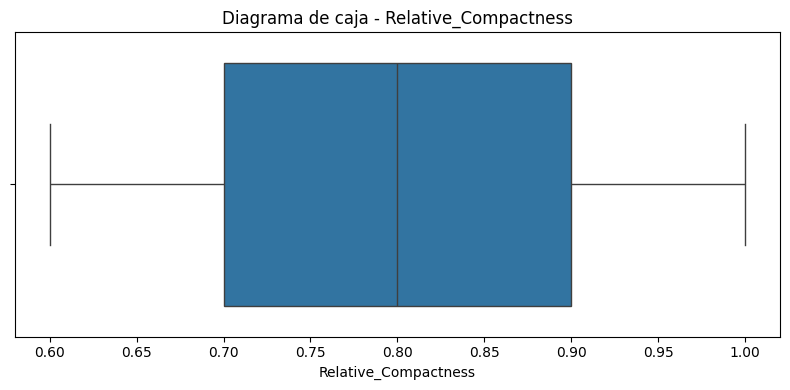

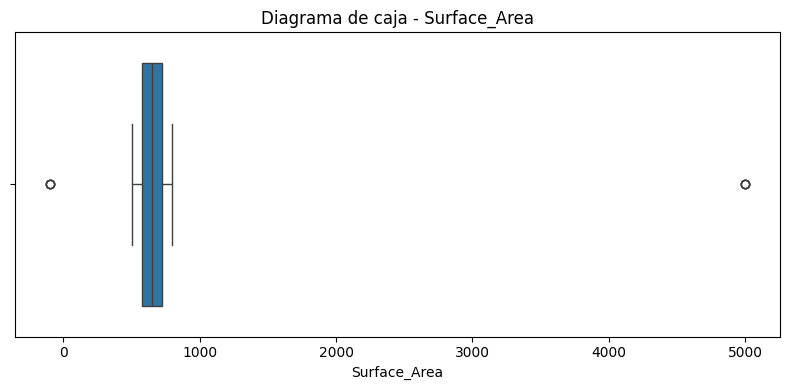

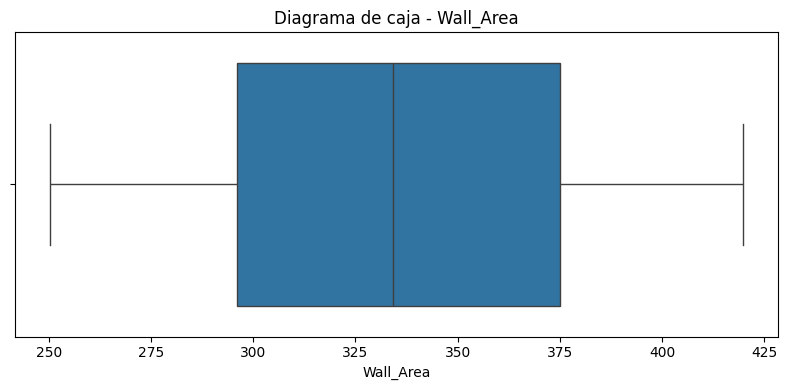

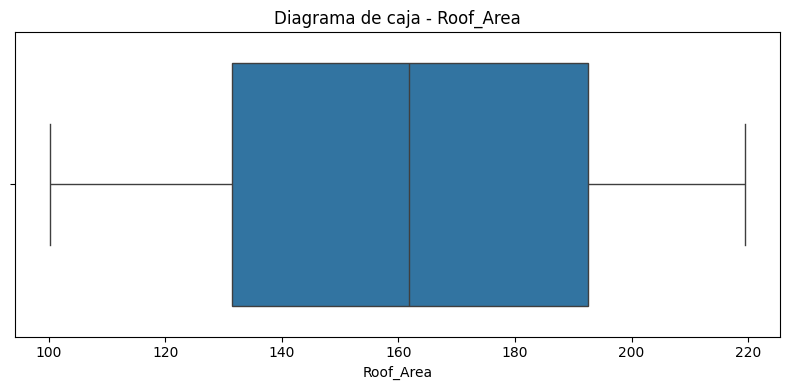

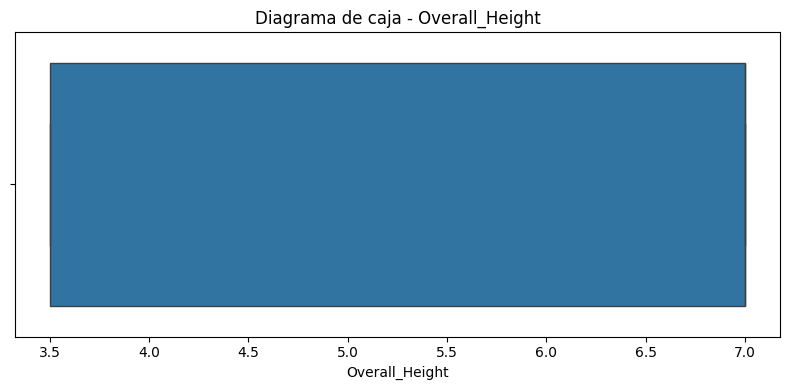

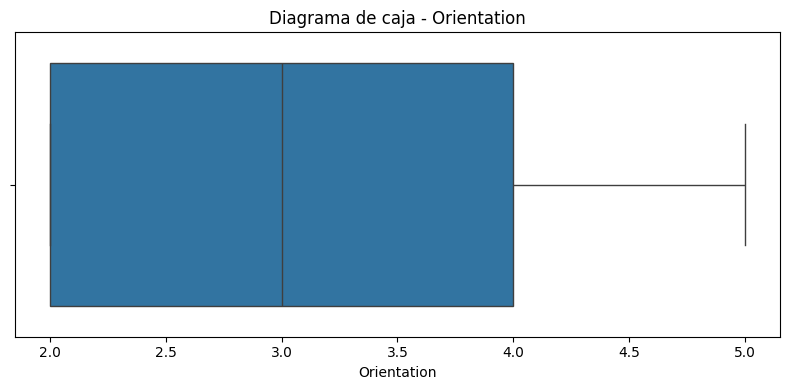

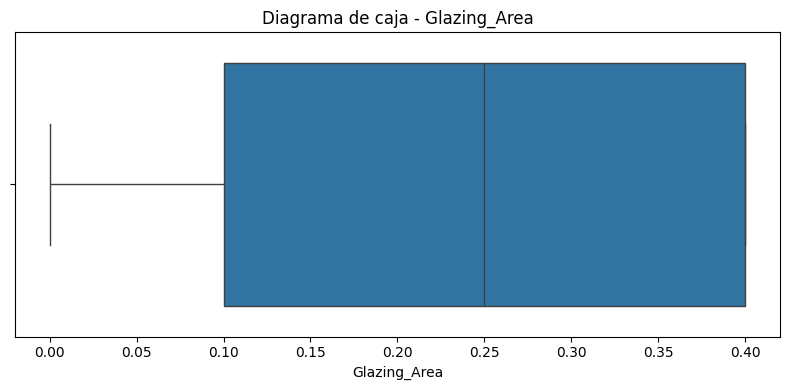

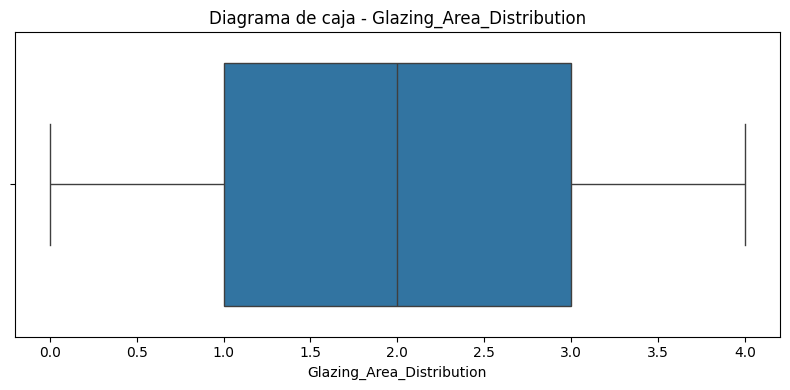

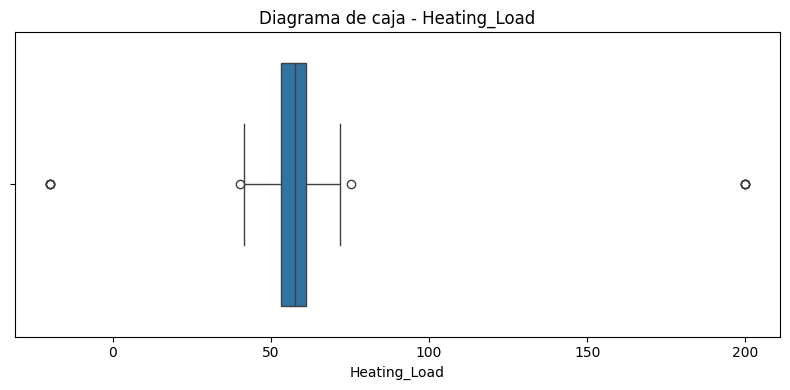

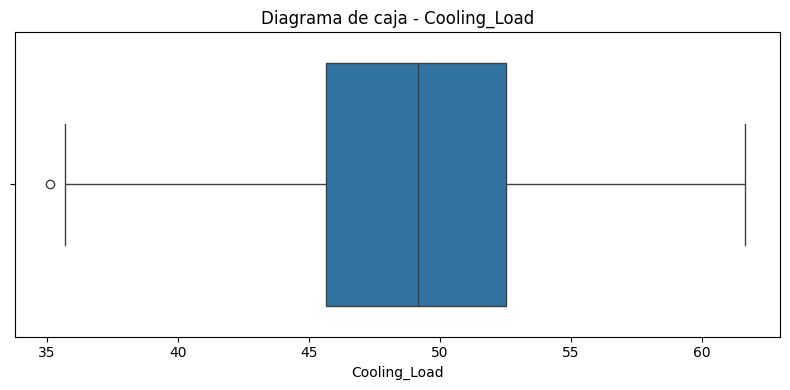

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

variables_numericas = df.select_dtypes(include='number').columns

for variable in variables_numericas:
    fig, ax = plt.subplots(figsize=(8, 4))
    
    sns.boxplot(x=df[variable], ax=ax)
    
    ax.set_title(f'Diagrama de caja - {variable}')
    ax.set_xlabel(variable)
    
    plt.tight_layout()
    
    display(fig)
    plt.close(fig)

In [26]:

valores_nulos = df.isnull().sum()

porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'Valores_Nulos': valores_nulos,
    'Porcentaje_Nulos': porcentaje_nulos.round(2)
})

print("Valores nulos por variable:")
display(tabla_nulos)

variables_numericas = df.select_dtypes(include='number').columns

resultado_atipicos = []

for variable in variables_numericas:
    
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    atipicos = (
        (df[variable] < limite_inferior) |
        (df[variable] > limite_superior)
    ).sum()
    
    resultado_atipicos.append({
        'Variable': variable,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Inferior': limite_inferior,
        'Limite_Superior': limite_superior,
        'Valores_Atipicos': atipicos,
        'Porcentaje_Atipicos': round((atipicos / len(df)) * 100, 2)
    })

tabla_atipicos = pd.DataFrame(resultado_atipicos)

print("\nValores atípicos por variable:")
display(tabla_atipicos)

Valores nulos por variable:


,Valores_Nulos,Porcentaje_Nulos
Relative_Compactness,100,10.0
Surface_Area,92,9.2
Wall_Area,100,10.0
Roof_Area,0,0.0
Overall_Height,0,0.0
Orientation,0,0.0
Glazing_Area,100,10.0
Glazing_Area_Distribution,0,0.0
Heating_Load,0,0.0
Cooling_Load,0,0.0



Valores atípicos por variable:


,Variable,Q1,Q3,IQR,Limite_Inferior,Limite_Superior,Valores_Atipicos,Porcentaje_Atipicos
0,Relative_Compactness,0.700000,0.900000,0.200000,0.400000,1.200000,0,0.0
1,Surface_Area,575.120415,723.668225,148.547810,352.298699,946.489940,8,0.8
2,Wall_Area,295.990522,375.097164,79.106642,177.330559,493.757127,0,0.0
3,Roof_Area,131.390612,192.513784,61.123171,39.705855,284.198541,0,0.0
4,Overall_Height,3.500000,7.000000,3.500000,-1.750000,12.250000,0,0.0
5,Orientation,2.000000,4.000000,2.000000,-1.000000,7.000000,0,0.0
6,Glazing_Area,0.100000,0.400000,0.300000,-0.350000,0.850000,0,0.0
7,Glazing_Area_Distribution,1.000000,3.000000,2.000000,-2.000000,6.000000,0,0.0
8,Heating_Load,53.225369,61.183546,7.958177,41.288104,73.120811,10,1.0
9,Cooling_Load,45.652028,52.516908,6.864880,35.354708,62.814228,1,0.1


El análisis de calidad de los datos permitió identificar dos situaciones principales: valores faltantes y valores atípicos.

En cuanto a los valores faltantes, se encontraron datos ausentes en cuatro variables predictoras: Relative_Compactness (10%), Surface_Area (9,2%), Wall_Area (10%) y Glazing_Area (10%). Debido a que estas variables son necesarias para el modelo de regresión y los porcentajes de ausencia son relativamente altos, se utilizará KNN Imputer para estimar los valores faltantes sin eliminar las observaciones.

Respecto a los valores atípicos, el método IQR identificó 8 casos en Surface_Area (0,8%), 10 en Heating_Load (1%) y 1 en Cooling_Load (0,1%). La cantidad de valores atípicos es reducida en relación con las 1000 observaciones del conjunto de datos.

Los valores atípicos de Heating_Load y Cooling_Load requieren especial cuidado porque corresponden a las variables objetivo. Por esta razón, no se eliminarán ni imputarán automáticamente, ya que podrían representar comportamientos reales de la demanda energética.

## Paso 6. Imputación de valores faltantes mediante KNN

En esta etapa se realizará la imputación de los valores faltantes identificados en Relative_Compactness, Surface_Area, Wall_Area y Glazing_Area mediante el algoritmo KNN (K-Nearest Neighbors).

El método utilizará las características de los registros más similares para estimar los valores ausentes. Antes de aplicar KNN, las variables numéricas deberán ser escaladas, ya que el algoritmo utiliza distancias y las variables tienen diferentes rangos.

La imputación permitirá conservar las 1000 observaciones originales, evitando eliminar registros debido a los valores faltantes. Finalmente, se verificará que no queden valores nulos en el conjunto de datos.

In [27]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Variables predictoras
variables_X = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Roof_Area',
    'Overall_Height',
    'Orientation',
    'Glazing_Area',
    'Glazing_Area_Distribution'
]

# Escalar las variables antes de aplicar KNN
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df[variables_X])

# Aplicar imputación KNN
imputer = KNNImputer(n_neighbors=5)
X_imputado = imputer.fit_transform(X_escalado)

# Invertir el escalamiento
X_imputado = scaler.inverse_transform(X_imputado)

# Actualizar las variables predictoras en el DataFrame
df[variables_X] = X_imputado

# Verificar valores nulos después de la imputación
print("Valores nulos después de la imputación:")
display(df.isnull().sum())

Valores nulos después de la imputación:


Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

## Paso 7. Imputación de valores atípicos mediante KNN

En esta etapa se realizará la imputación de los valores atípicos previamente identificados utilizando el algoritmo KNN (K-Nearest Neighbors). Los valores considerados atípicos mediante el método IQR serán tratados como valores que requieren estimación y serán reemplazados utilizando los valores de los registros más similares.

Al igual que en la imputación de valores faltantes, se utilizarán las variables estandarizadas para calcular las distancias entre observaciones. De esta manera, se busca conservar las 1000 observaciones y reducir la influencia de valores extremos sobre el posterior entrenamiento de los modelos de regresión.

In [28]:
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Variables numéricas
variables_numericas = df.select_dtypes(include='number').columns

# Crear una copia para detectar y reemplazar valores atípicos
df_knn = df[variables_numericas].copy()


for variable in variables_numericas:

    Q1 = df_knn[variable].quantile(0.25)
    Q3 = df_knn[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Convertir valores atípicos en NaN
    df_knn.loc[
        (df_knn[variable] < limite_inferior) |
        (df_knn[variable] > limite_superior),
        variable
    ] = np.nan

scaler = StandardScaler()

df_escalado = scaler.fit_transform(df_knn)


imputer = KNNImputer(n_neighbors=5)

df_imputado = imputer.fit_transform(df_escalado)

df_imputado = scaler.inverse_transform(df_imputado)

df[variables_numericas] = df_imputado


print("Valores nulos después del tratamiento:")
display(df.isnull().sum())

Valores nulos después del tratamiento:


Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

In [29]:
df.describe()
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       1000 non-null   float64
 1   Surface_Area               1000 non-null   float64
 2   Wall_Area                  1000 non-null   float64
 3   Roof_Area                  1000 non-null   float64
 4   Overall_Height             1000 non-null   float64
 5   Orientation                1000 non-null   float64
 6   Glazing_Area               1000 non-null   float64
 7   Glazing_Area_Distribution  1000 non-null   float64
 8   Heating_Load               1000 non-null   float64
 9   Cooling_Load               1000 non-null   float64
dtypes: float64(10)
memory usage: 78.3 KB


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.74,665.429402,328.616746,138.193576,3.5,5.0,0.40,3.0,55.181024,53.629897
1,0.85,786.761968,419.578324,194.659517,7.0,5.0,0.10,0.0,65.940416,52.778385
2,0.94,627.172679,378.012514,109.969135,3.5,5.0,0.25,3.0,52.301413,43.391075
3,0.83,719.556163,398.526872,118.328080,7.0,2.0,0.10,2.0,62.648324,56.687024
4,0.82,558.936051,309.682859,143.892194,3.5,4.0,0.10,3.0,46.717343,41.729641


Después del tratamiento de los valores faltantes y atípicos mediante KNN, el conjunto de datos conserva las 1000 observaciones originales y las 10 variables seleccionadas. Todas las variables presentan 1000 valores no nulos, lo que confirma que no quedaron datos faltantes.

Además, todas las variables fueron convertidas a tipo numérico float64, facilitando su utilización en los modelos de Machine Learning. Los valores identificados previamente como atípicos fueron reemplazados mediante estimaciones basadas en observaciones similares, evitando eliminar registros.

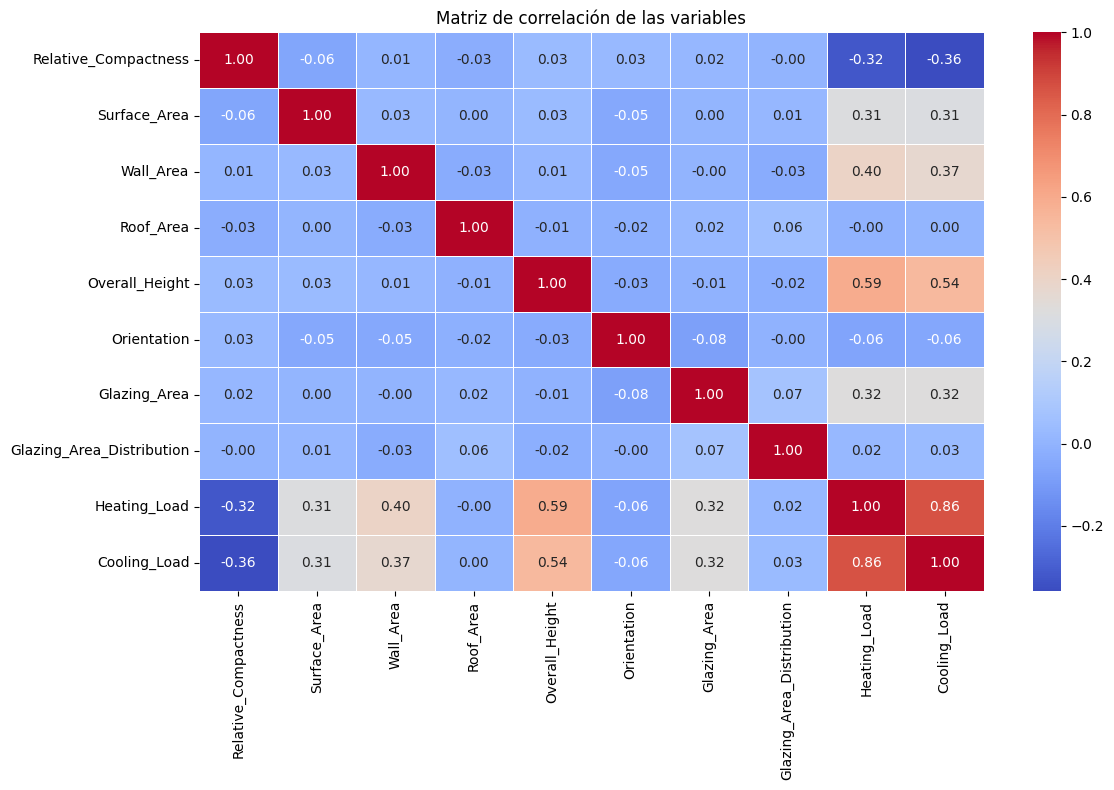

Tabla de correlación:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
Relative_Compactness,1.00,-0.06,0.01,-0.03,0.03,0.03,0.02,-0.00,-0.32,-0.36
Surface_Area,-0.06,1.00,0.03,0.00,0.03,-0.05,0.00,0.01,0.31,0.31
Wall_Area,0.01,0.03,1.00,-0.03,0.01,-0.05,-0.00,-0.03,0.40,0.37
Roof_Area,-0.03,0.00,-0.03,1.00,-0.01,-0.02,0.02,0.06,-0.00,0.00
Overall_Height,0.03,0.03,0.01,-0.01,1.00,-0.03,-0.01,-0.02,0.59,0.54
Orientation,0.03,-0.05,-0.05,-0.02,-0.03,1.00,-0.08,-0.00,-0.06,-0.06
Glazing_Area,0.02,0.00,-0.00,0.02,-0.01,-0.08,1.00,0.07,0.32,0.32
Glazing_Area_Distribution,-0.00,0.01,-0.03,0.06,-0.02,-0.00,0.07,1.00,0.02,0.03
Heating_Load,-0.32,0.31,0.40,-0.00,0.59,-0.06,0.32,0.02,1.00,0.86
Cooling_Load,-0.36,0.31,0.37,0.00,0.54,-0.06,0.32,0.03,0.86,1.00


In [30]:
%matplotlib inline



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include='number')

# Calcular matriz de correlación
correlacion = variables_numericas.corr()

# =========================
# GRÁFICA DE CORRELACIÓN
# =========================

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de correlación de las variables')
plt.tight_layout()
plt.show()

# =========================
# TABLA DE CORRELACIÓN
# =========================

print("Tabla de correlación:")

display(correlacion.round(2))

La matriz de correlación muestra las relaciones lineales entre las variables después del tratamiento de valores faltantes y atípicos.

Overall_Height presenta la mayor correlación positiva con Heating_Load (0.59) y con Cooling_Load (0.54), por lo que la altura del edificio tiene una relación importante con la demanda energética.
Wall_Area presenta una correlación positiva moderada con Heating_Load (0.40) y Cooling_Load (0.37).
Glazing_Area presenta una relación positiva moderada-baja con ambas variables objetivo (0.32).
Surface_Area presenta una correlación positiva de 0.31 con ambas demandas.
Relative_Compactness presenta una correlación negativa moderada-baja con Heating_Load (-0.32) y Cooling_Load (-0.36).
Orientation y Glazing_Area_Distribution presentan correlaciones muy bajas con las variables objetivo, cercanas a cero.
Heating_Load y Cooling_Load tienen una correlación alta de 0.86, indicando que ambos tipos de demanda energética están fuertemente relacionados.

En cuanto a las relaciones entre las variables predictoras, la mayoría de las correlaciones son cercanas a cero. Esto indica que no se observa una multicolinealidad fuerte entre los predictores, lo cual es favorable para la construcción de los modelos.

## Paso 8. Formulación de la hipótesis nula

Para este proyecto, la hipótesis nula debe plantearse sobre la relación entre las variables predictoras y las variables objetivo (Heating_Load y Cooling_Load).

Una formulación adecuada sería:

H₀ (Hipótesis nula): No existe una relación estadísticamente significativa entre las características físicas y de diseño de los edificios y su demanda energética de calefacción y refrigeración.

H₁ (Hipótesis alternativa): Existe una relación estadísticamente significativa entre las características físicas y de diseño de los edificios y su demanda energética de calefacción y refrigeración.

In [31]:
from scipy.stats import pearsonr
import pandas as pd

# Variables predictoras
variables_X = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Roof_Area',
    'Overall_Height',
    'Orientation',
    'Glazing_Area',
    'Glazing_Area_Distribution'
]

# Variables objetivo
variables_y = [
    'Heating_Load',
    'Cooling_Load'
]

resultados = []

# Prueba de correlación de Pearson
for variable_x in variables_X:
    for variable_y in variables_y:
        
        r, p_valor = pearsonr(df[variable_x], df[variable_y])
        
        resultados.append({
            'Variable_Predictora': variable_x,
            'Variable_Objetivo': variable_y,
            'Correlacion_Pearson': round(r, 3),
            'P_valor': round(p_valor, 4),
            'Resultado': 'Rechazar H0' if p_valor < 0.05 else 'No rechazar H0'
        })

# Crear tabla de resultados
tabla_hipotesis = pd.DataFrame(resultados)

print("Resultados de la prueba de hipótesis:")
display(tabla_hipotesis)

Resultados de la prueba de hipótesis:


,Variable_Predictora,Variable_Objetivo,Correlacion_Pearson,P_valor,Resultado
0,Relative_Compactness,Heating_Load,-0.324,0.0000,Rechazar H0
1,Relative_Compactness,Cooling_Load,-0.358,0.0000,Rechazar H0
2,Surface_Area,Heating_Load,0.310,0.0000,Rechazar H0
3,Surface_Area,Cooling_Load,0.306,0.0000,Rechazar H0
4,Wall_Area,Heating_Load,0.402,0.0000,Rechazar H0
5,Wall_Area,Cooling_Load,0.372,0.0000,Rechazar H0
6,Roof_Area,Heating_Load,-0.004,0.9030,No rechazar H0
7,Roof_Area,Cooling_Load,0.003,0.9235,No rechazar H0
8,Overall_Height,Heating_Load,0.592,0.0000,Rechazar H0
9,Overall_Height,Cooling_Load,0.544,0.0000,Rechazar H0


A partir de la prueba de correlación de Pearson y considerando un nivel de significancia de α = 0.05, se evaluó si existe evidencia estadística de una relación lineal entre las características físicas del edificio y las variables de demanda energética.

Los resultados muestran que Overall_Height es la variable con mayor asociación lineal con la demanda energética, presentando correlaciones de 0.592 con Heating_Load y 0.544 con Cooling_Load, ambas con valores p < 0.05. Esto indica una relación positiva y estadísticamente significativa.

También se identifican relaciones significativas para Wall_Area, Relative_Compactness, Glazing_Area y Surface_Area. En particular, Wall_Area presenta correlaciones de 0.402 con Heating_Load y 0.372 con Cooling_Load. Por su parte, Relative_Compactness presenta una relación inversa con ambas variables objetivo, mientras que Surface_Area y Glazing_Area presentan relaciones positivas.

En contraste, Roof_Area, Orientation y Glazing_Area_Distribution no presentan evidencia estadísticamente significativa de una relación lineal con las variables objetivo bajo el nivel de significancia establecido, dado que sus valores p son superiores a 0.05.

Desde una perspectiva analítica, estos resultados permiten concluir que la demanda energética está asociada principalmente con determinadas características estructurales y de diseño del edificio, especialmente la altura, el área de paredes, la compacidad, el área superficial y el área de acristalamiento. No obstante, que una variable no presente una correlación lineal significativa no implica necesariamente que carezca de capacidad predictiva, ya que puede participar en relaciones no lineales o interacciones con otras variables.

<Figure size 1200x700 with 0 Axes>

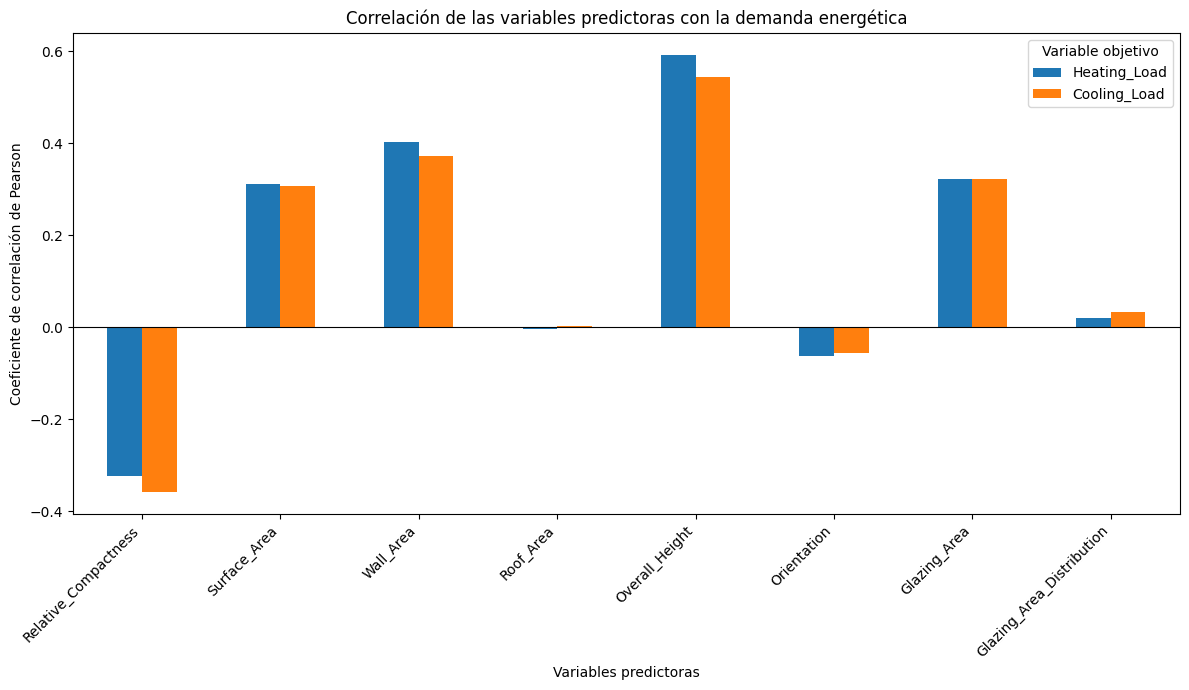

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar únicamente las correlaciones con las variables objetivo
correlaciones_objetivo = correlacion[
    ['Heating_Load', 'Cooling_Load']
].drop(['Heating_Load', 'Cooling_Load'])

# Crear gráfico
plt.figure(figsize=(12, 7))

correlaciones_objetivo.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.axhline(y=0, color='black', linewidth=0.8)

plt.title('Correlación de las variables predictoras con la demanda energética')
plt.xlabel('Variables predictoras')
plt.ylabel('Coeficiente de correlación de Pearson')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Variable objetivo')
plt.tight_layout()
plt.show()

## Paso 10. Selección final de variables

Con base en el análisis de correlación y la prueba de hipótesis, se eliminan las variables Roof_Area, Orientation y Glazing_Area_Distribution, debido a que presentaron una relación lineal despreciable con las dos variables objetivo.

El conjunto de datos queda conformado por cinco variables predictoras: Relative_Compactness, Surface_Area, Wall_Area, Overall_Height y Glazing_Area, mientras que Heating_Load y Cooling_Load se mantienen como variables objetivo para el desarrollo de los modelos predictivos.

In [33]:

variables_eliminar = [
    'Roof_Area',
    'Orientation',
    'Glazing_Area_Distribution'
]

df = df.drop(columns=variables_eliminar)

print("Variables después de la selección:")
print(df.columns.tolist())

print("\nDimensiones del dataset:")
print(df.shape)


Variables después de la selección:
['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Overall_Height', 'Glazing_Area', 'Heating_Load', 'Cooling_Load']

Dimensiones del dataset:
(1000, 7)


In [34]:
print(df.describe())
print(df.info())
print(df.head())

       Relative_Compactness  Surface_Area    Wall_Area  Overall_Height  \
count           1000.000000   1000.000000  1000.000000     1000.000000   
mean               0.799426    650.912401   335.306383        5.309500   
std                0.110112     82.303714    45.492056        1.749863   
min                0.600000    493.733657   250.202966        3.500000   
25%                0.710000    584.010859   299.371830        3.500000   
50%                0.800000    653.276116   333.306576        7.000000   
75%                0.890000    716.054994   371.209560        7.000000   
max                1.000000    799.551944   419.905531        7.000000   

       Glazing_Area  Heating_Load  Cooling_Load  
count  1.000000e+03   1000.000000   1000.000000  
mean   1.919400e-01     57.264669     49.055682  
std    1.449277e-01      5.840168      4.835109  
min   -2.775558e-17     41.321521     35.681701  
25%    1.000000e-01     53.249588     45.652028  
50%    2.300000e-01     57.535894

Después de la selección y el tratamiento de los datos, el conjunto final contiene 1000 registros y 7 variables, todas de tipo numérico (float64). No se presentan valores nulos.

El dataset está compuesto por cinco variables predictoras: Relative_Compactness, Surface_Area, Wall_Area, Overall_Height y Glazing_Area, y dos variables objetivo: Heating_Load y Cooling_Load.

Las variables presentan rangos y valores estadísticos coherentes con las características de los edificios. Heating_Load presenta una media de 57.26, mientras que Cooling_Load tiene una media de 49.06. La desviación estándar indica una variabilidad moderada en ambas variables objetivo.

## Paso 11. Escalamiento y normalización de todas las variables

Se aplicará MinMaxScaler a todas las variables del conjunto de datos, incluyendo las variables predictoras y las variables objetivo. De esta manera, todos los valores serán transformados a un rango entre 0 y 1, facilitando la comparación entre variables y preparando el conjunto de datos para las siguientes etapas del modelado.

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

print("Dataset después del escalamiento:")
display(df_scaled.head())

print("\nEstadísticas del dataset escalado:")
display(df_scaled.describe())

Dataset después del escalamiento:


,Relative_Compactness,Surface_Area,Wall_Area,Overall_Height,Glazing_Area,Heating_Load,Cooling_Load
0,0.350,0.561431,0.462066,0.0,1.000,0.453188,0.691279
1,0.625,0.958178,0.998072,1.0,0.250,0.805007,0.658483
2,0.850,0.436334,0.753139,0.0,0.625,0.359029,0.296928
3,0.575,0.738421,0.874023,1.0,0.250,0.697360,0.809025
4,0.550,0.213206,0.350495,0.0,0.250,0.176437,0.232938



Estadísticas del dataset escalado:


,Relative_Compactness,Surface_Area,Wall_Area,Overall_Height,Glazing_Area,Heating_Load,Cooling_Load
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.498565,0.513961,0.501486,0.517000,0.479850,0.521321,0.515102
std,0.275280,0.269126,0.268069,0.499961,0.362319,0.190966,0.186225
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.275000,0.295199,0.289736,0.000000,0.250000,0.390033,0.384010
50%,0.500000,0.521690,0.489702,1.000000,0.575000,0.530190,0.518496
75%,0.725000,0.726972,0.713051,1.000000,0.625000,0.648366,0.648412
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


La normalización se realizó correctamente. Todas las variables fueron transformadas al rango [0, 1], como se observa en los valores mínimos y máximos.

Overall_Height mantiene únicamente valores 0 y 1 porque originalmente solo tenía dos niveles (3.5 y 7.0). Las variables objetivo Heating_Load y Cooling_Load también quedaron correctamente normalizadas.

## Paso 12. Evaluación del modelo de regresión lineal multivariada

Se construirá y evaluará un modelo de regresión lineal multivariada para predecir simultáneamente Heating_Load y Cooling_Load a partir de las cinco variables predictoras seleccionadas. Se analizarán los coeficientes obtenidos para identificar la influencia de cada variable sobre las predicciones y se utilizarán las métricas MAE, MSE, RMSE, MAPE y R² para evaluar el desempeño del modelo.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

metricas = []

for i, variable in enumerate(variables_y):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mape = mean_absolute_percentage_error(
        y_test.iloc[:, i],
        y_pred[:, i]
    ) * 100

    metricas.append({
        'Variable_Objetivo': variable,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

tabla_metricas = pd.DataFrame(metricas)

print("Métricas de evaluación:")
display(tabla_metricas.round(4))

Métricas de evaluación:


,Variable_Objetivo,MAE,MSE,RMSE,MAPE (%),R²
0,Heating_Load,0.0627,0.0062,0.0788,18.6241,0.8221
1,Cooling_Load,0.0722,0.0080,0.0894,20.3107,0.7595


El modelo presenta un desempeño aceptable para ambas variables objetivo, aunque obtiene mejores resultados para Heating_Load.

Heating_Load: R² = 0.8221, lo que indica que el modelo explica aproximadamente el 82.21 % de la variabilidad de la demanda de calefacción. El RMSE es 0.0788 y el MAPE es 18.62 %.
Cooling_Load: R² = 0.7595, por lo que el modelo explica aproximadamente el 75.95 % de la variabilidad de la demanda de refrigeración. El RMSE es 0.0894 y el MAPE es 20.31 %.

En comparación, el modelo presenta mayor capacidad predictiva para Heating_Load que para Cooling_Load, debido a su mayor R² y menores valores de error. En general, los resultados muestran que la regresión lineal multivariada logra representar una parte importante del comportamiento de ambas variables objetivo.

## Paso 13. Modelos de árbol de decisión

Se entrenarán dos modelos de árbol de decisión de regresión para predecir Heating_Load y Cooling_Load. El primer modelo utilizará una división de los datos de 70 % para entrenamiento y 30 % para prueba, mientras que el segundo utilizará validación cruzada de 5 particiones (5-fold Cross Validation).

Para ambos modelos se calcularán las métricas MAE, MSE, RMSE, MAPE y R², con el propósito de evaluar y comparar su capacidad predictiva. Además, se generarán representaciones gráficas de los árboles para visualizar las variables y condiciones utilizadas en las decisiones del modelo.

Métricas del árbol con división 70/30:


,Modelo,Variable_Objetivo,MAE,MSE,RMSE,MAPE (%),R²
0,Árbol 70/30,Heating_Load,0.0959,0.0134,0.1157,25.9118,0.6207
1,Árbol 70/30,Cooling_Load,0.1035,0.0179,0.1338,26.0037,0.4657


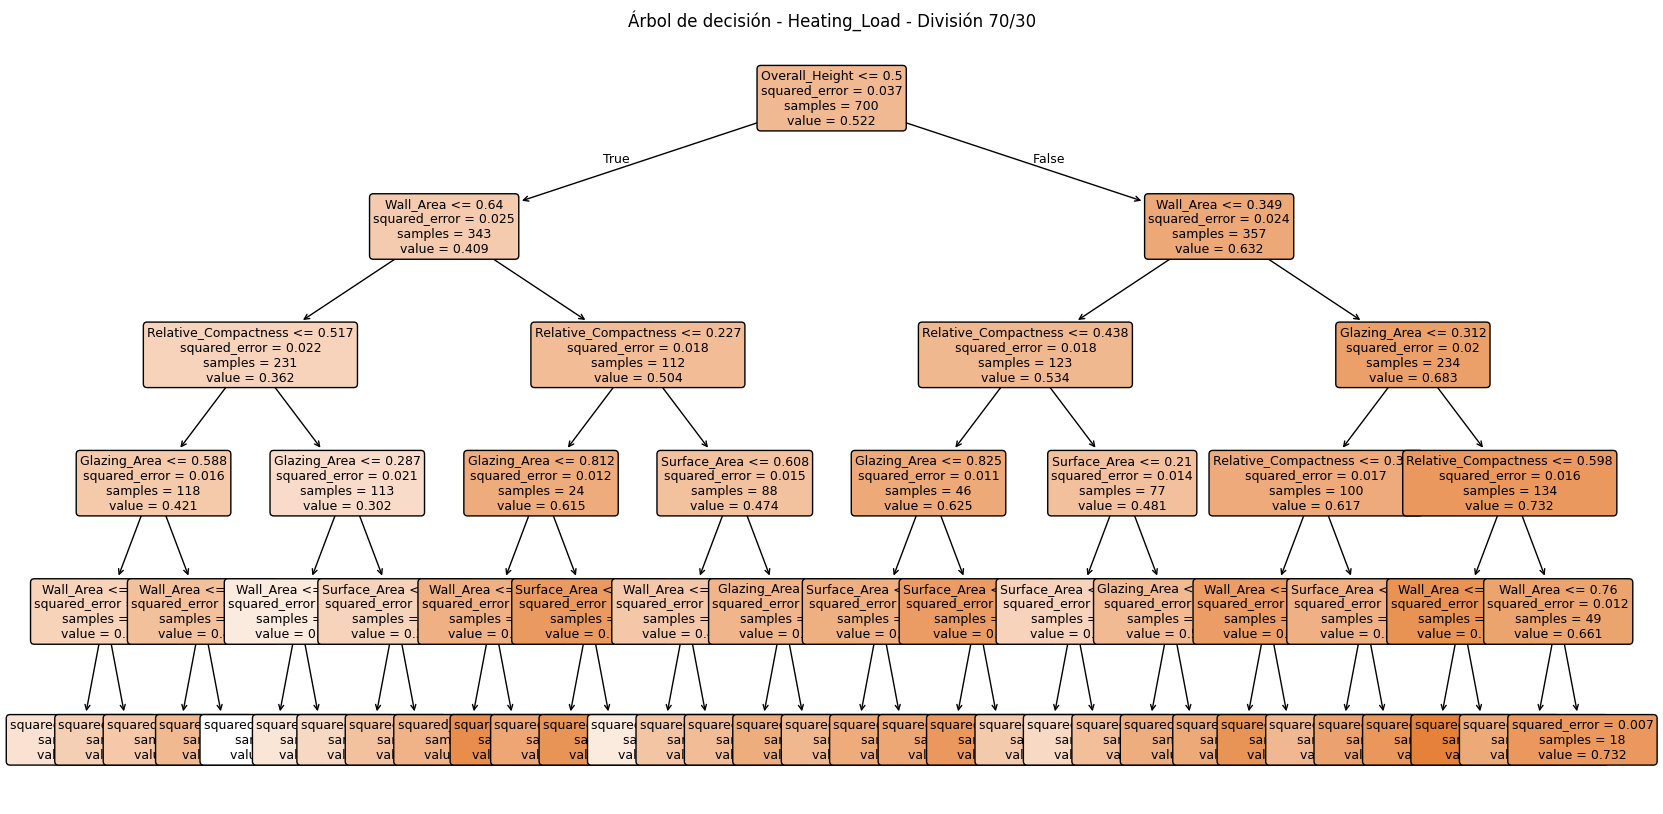

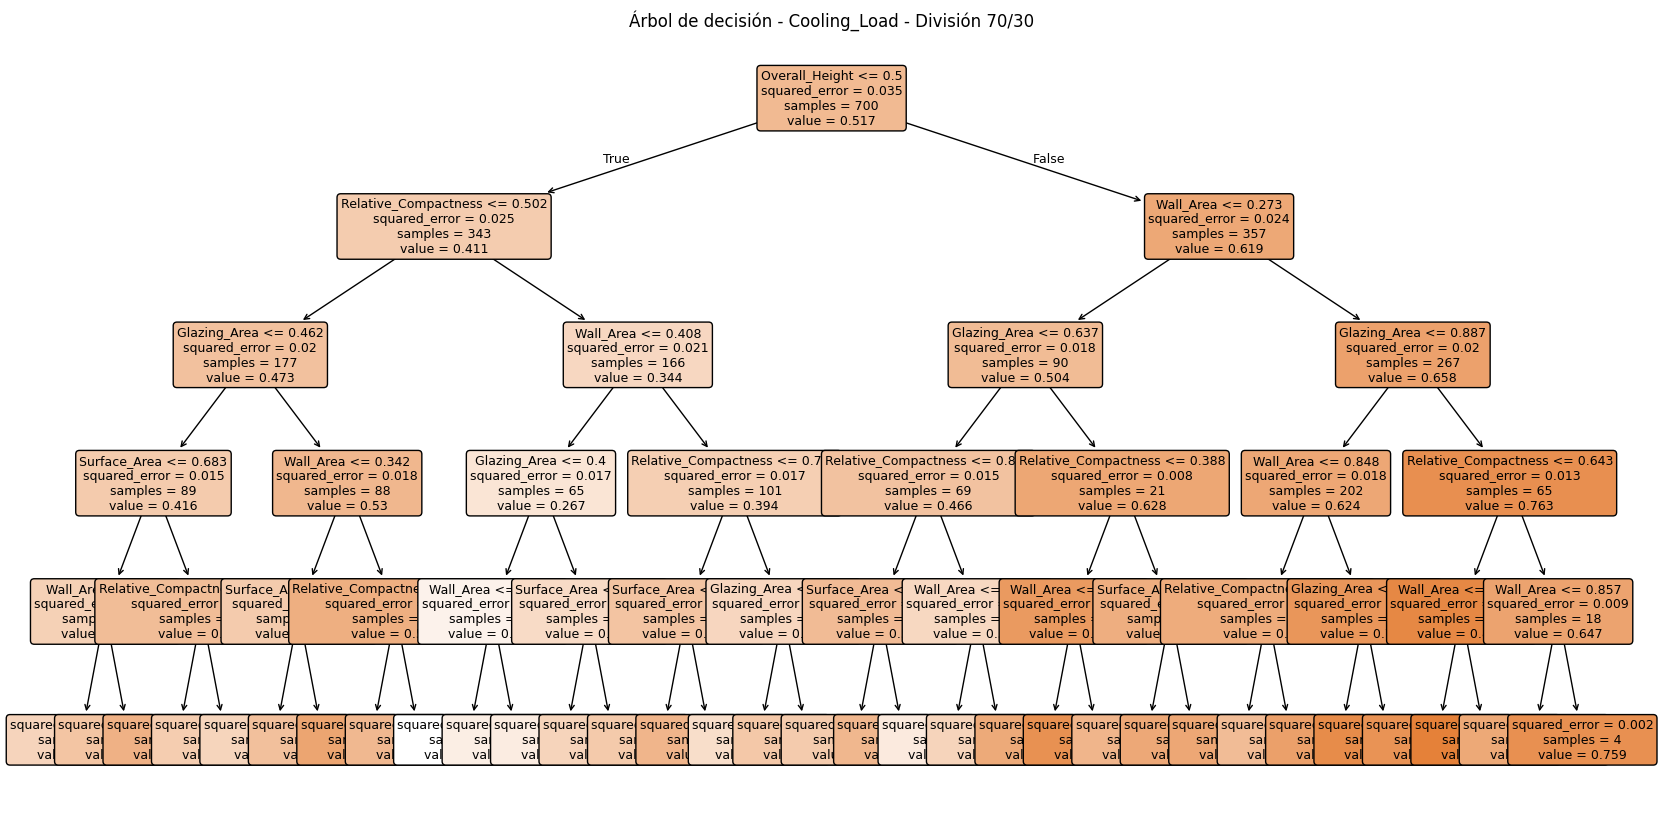

Métricas del árbol con Cross Validation:


,Modelo,Variable_Objetivo,MAE,MSE,RMSE,MAPE (%),R²
0,Árbol Cross Validation,Heating_Load,0.0979,0.0148,0.1216,1.076679e+14,0.5944
1,Árbol Cross Validation,Cooling_Load,0.0985,0.0154,0.1240,1.683579e+14,0.5561


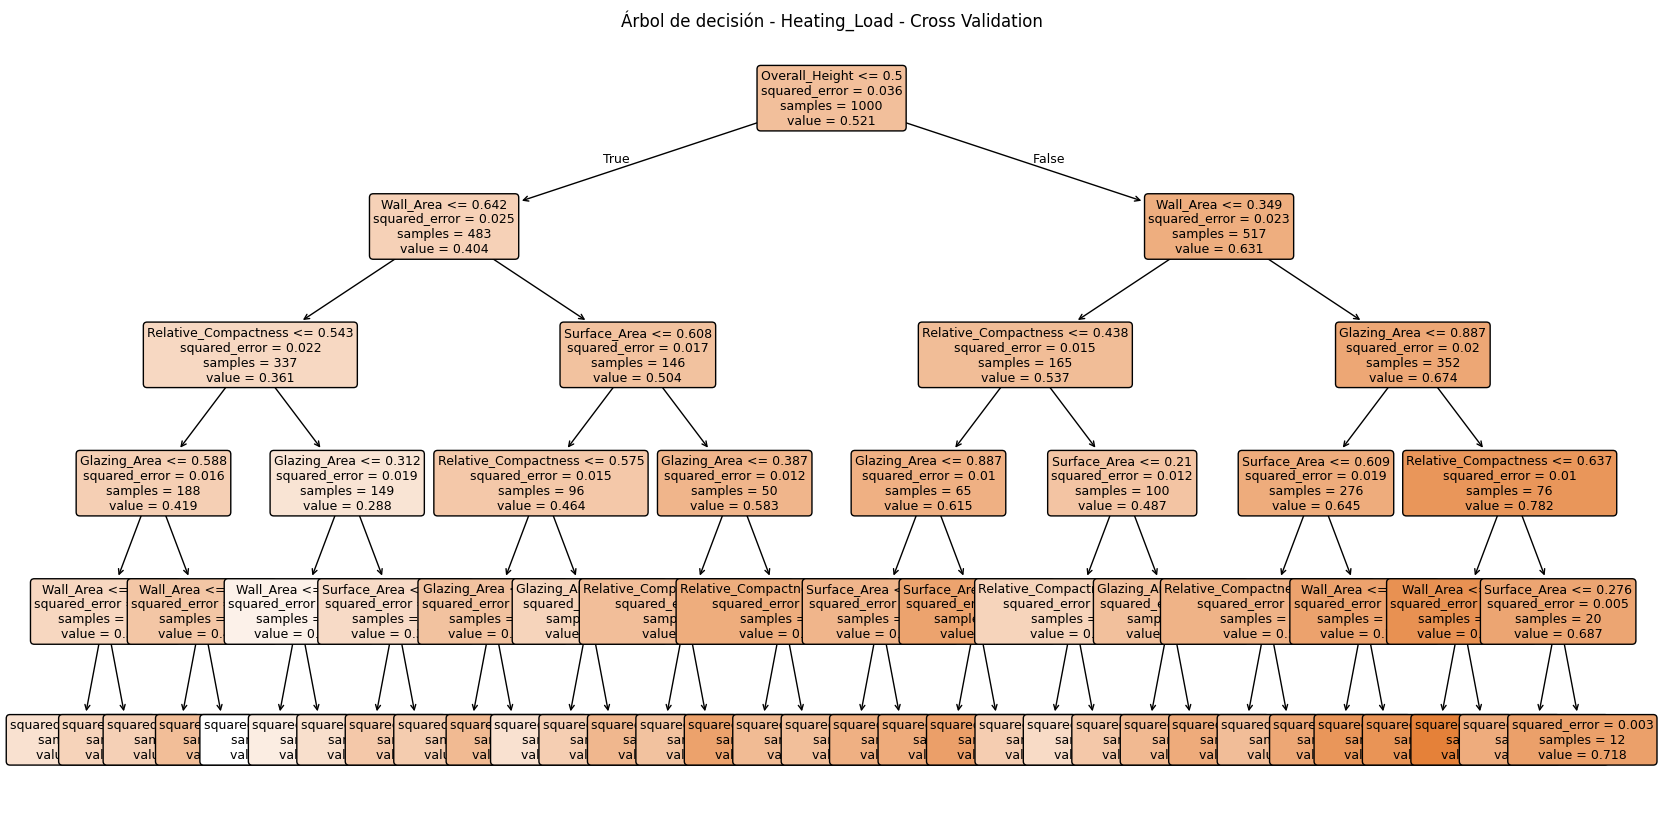

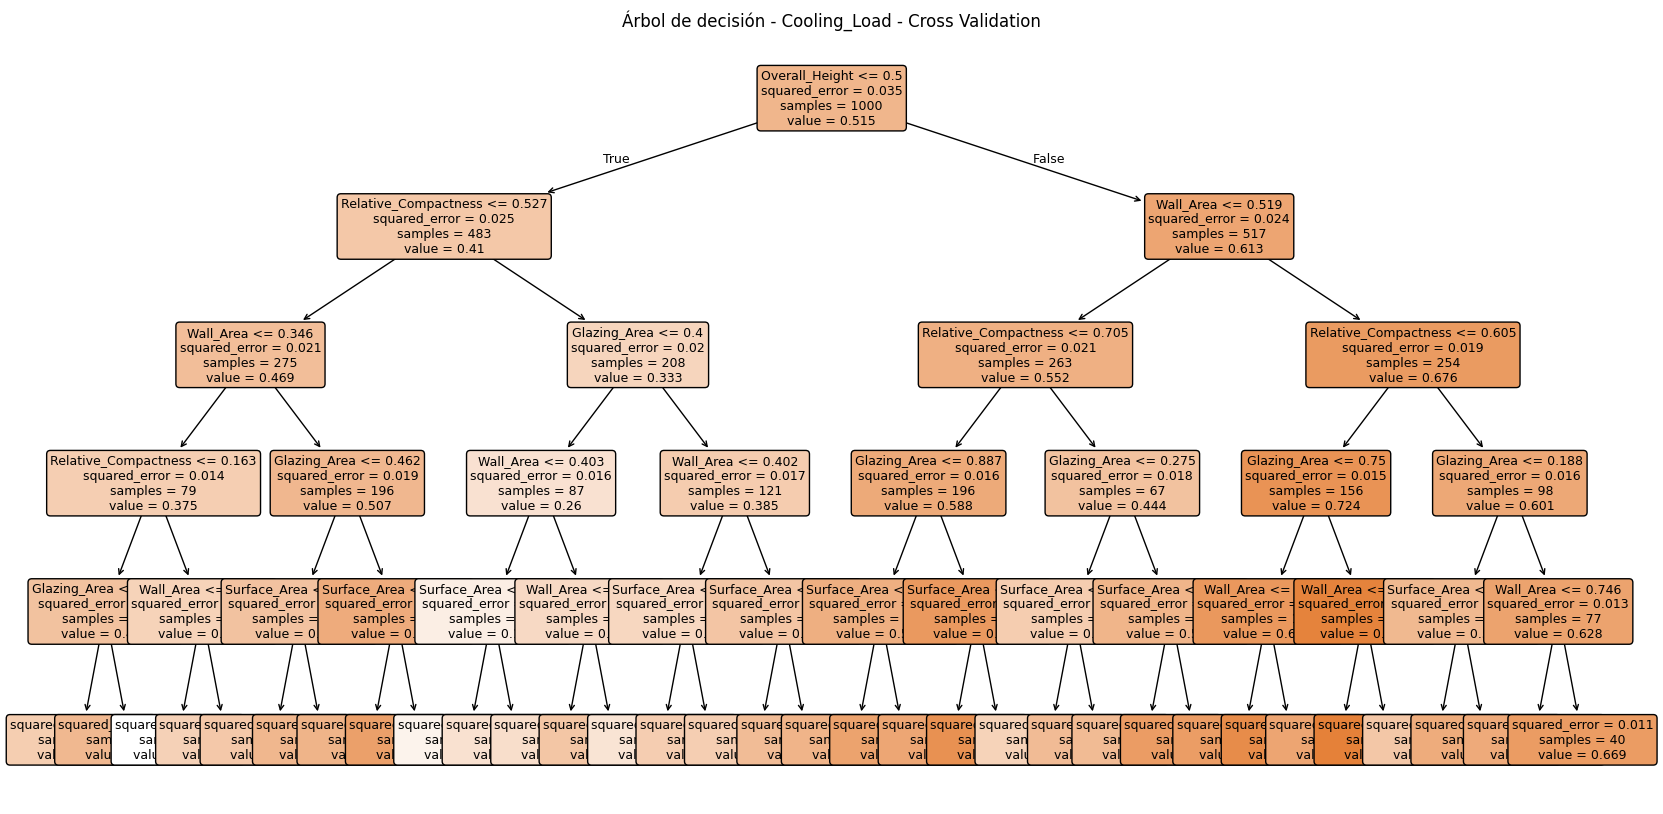

Comparación de modelos:


,Modelo,Variable_Objetivo,MAE,MSE,RMSE,MAPE (%),R²
0,Árbol 70/30,Heating_Load,0.0959,0.0134,0.1157,2.591180e+01,0.6207
1,Árbol 70/30,Cooling_Load,0.1035,0.0179,0.1338,2.600370e+01,0.4657
2,Árbol Cross Validation,Heating_Load,0.0979,0.0148,0.1216,1.076679e+14,0.5944
3,Árbol Cross Validation,Cooling_Load,0.0985,0.0154,0.1240,1.683579e+14,0.5561


In [38]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Variables predictoras
variables_X = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Overall_Height',
    'Glazing_Area'
]

# Variables objetivo
variables_y = [
    'Heating_Load',
    'Cooling_Load'
]

X = df_scaled[variables_X]
y = df_scaled[variables_y]

# ==========================================================
# MODELO 1: ÁRBOL DE DECISIÓN CON DIVISIÓN 70/30
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

modelos_7030 = {}
predicciones_7030 = {}

for variable in variables_y:

    modelo = DecisionTreeRegressor(
        random_state=42,
        max_depth=5
    )

    modelo.fit(X_train, y_train[variable])

    y_pred = modelo.predict(X_test)

    modelos_7030[variable] = modelo
    predicciones_7030[variable] = y_pred

# ==========================================================
# MÉTRICAS MODELO 70/30
# ==========================================================

metricas_7030 = []

for variable in variables_y:

    y_real = y_test[variable]
    y_pred = predicciones_7030[variable]

    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    r2 = r2_score(y_real, y_pred)

    metricas_7030.append({
        'Modelo': 'Árbol 70/30',
        'Variable_Objetivo': variable,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

tabla_7030 = pd.DataFrame(metricas_7030)

print("Métricas del árbol con división 70/30:")
display(tabla_7030.round(4))


# ==========================================================
# GRAFICAR ÁRBOLES 70/30
# ==========================================================

for variable in variables_y:

    plt.figure(figsize=(20, 10))

    plot_tree(
        modelos_7030[variable],
        feature_names=variables_X,
        filled=True,
        rounded=True,
        fontsize=9
    )

    plt.title(f'Árbol de decisión - {variable} - División 70/30')
    plt.show()


# ==========================================================
# MODELO 2: ÁRBOL DE DECISIÓN CON CROSS VALIDATION
# ==========================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelos_cv = {}
predicciones_cv = {}

for variable in variables_y:

    modelo = DecisionTreeRegressor(
        random_state=42,
        max_depth=5
    )

    y_pred_cv = cross_val_predict(
        modelo,
        X,
        y[variable],
        cv=kf
    )

    # Entrenar modelo final con todos los datos
    modelo.fit(X, y[variable])

    modelos_cv[variable] = modelo
    predicciones_cv[variable] = y_pred_cv


# ==========================================================
# MÉTRICAS CROSS VALIDATION
# ==========================================================

metricas_cv = []

for variable in variables_y:

    y_real = y[variable]
    y_pred = predicciones_cv[variable]

    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    r2 = r2_score(y_real, y_pred)

    metricas_cv.append({
        'Modelo': 'Árbol Cross Validation',
        'Variable_Objetivo': variable,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

tabla_cv = pd.DataFrame(metricas_cv)

print("Métricas del árbol con Cross Validation:")
display(tabla_cv.round(4))


# ==========================================================
# GRAFICAR ÁRBOLES CROSS VALIDATION
# ==========================================================

for variable in variables_y:

    plt.figure(figsize=(20, 10))

    plot_tree(
        modelos_cv[variable],
        feature_names=variables_X,
        filled=True,
        rounded=True,
        fontsize=9
    )

    plt.title(f'Árbol de decisión - {variable} - Cross Validation')
    plt.show()


# ==========================================================
# COMPARACIÓN DE LOS DOS MÉTODOS
# ==========================================================

comparacion_arboles = pd.concat(
    [tabla_7030, tabla_cv],
    ignore_index=True
)

print("Comparación de modelos:")
display(comparacion_arboles.round(4))

Los resultados muestran que los árboles de decisión presentan un desempeño inferior al modelo de regresión lineal multivariada obtenido anteriormente.

Para el modelo con división 70/30, el árbol obtuvo un R² de 0.6207 para Heating_Load y 0.4657 para Cooling_Load. Esto significa que explica aproximadamente el 62.07 % y 46.57 % de la variabilidad, respectivamente.

Con Cross Validation, el desempeño fue de R² = 0.5944 para Heating_Load y R² = 0.5561 para Cooling_Load. En este caso, el modelo mejora ligeramente para Cooling_Load, pero disminuye para Heating_Load.

Los valores de MAE y RMSE también muestran errores moderados. Sin embargo, los valores extremadamente altos del MAPE en Cross Validation (1.07e+14 y 1.68e+14) indican un problema numérico causado por valores de y cercanos a cero después de la normalización MinMax. Estos valores de MAPE no deben interpretarse como errores porcentuales reales.

## Paso 14. Ajuste y comparación de modelos mediante GridSearchCV

Se realizará el ajuste de hiperparámetros mediante GridSearchCV para los modelos de árbol de decisión, Random Forest, SVM, KNN, red neuronal y los métodos de ensamble Bagging, Boosting y Stacking. Para cada algoritmo se evaluará el desempeño antes y después del ajuste de hiperparámetros, utilizando MAPE como métrica principal de comparación.

El objetivo es identificar la configuración de hiperparámetros que permita obtener el menor error porcentual en la predicción de Heating_Load y Cooling_Load. Finalmente, se compararán todos los modelos para determinar cuál presenta el mejor desempeño predictivo para cada variable objetivo.

In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    AdaBoostRegressor,
    StackingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd
import numpy as np

# ==========================================================
# 1. VARIABLES
# ==========================================================

variables_X = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Overall_Height',
    'Glazing_Area'
]

variables_y = [
    'Heating_Load',
    'Cooling_Load'
]

# X normalizado
X = df_scaled[variables_X]

# y ORIGINAL
y = df[variables_y]

# División 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# ==========================================================
# 2. MODELOS BASE
# ==========================================================

modelos_base = {

    'Decision Tree': DecisionTreeRegressor(
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        random_state=42
    ),

    'SVM': MultiOutputRegressor(
        SVR()
    ),

    'KNN': MultiOutputRegressor(
        KNeighborsRegressor()
    ),

    'Red Neuronal': MLPRegressor(
        random_state=42,
        max_iter=2000
    ),

    'Bagging': BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42
    ),

    'Boosting': MultiOutputRegressor(
        AdaBoostRegressor(
            random_state=42
        )
    )
}


# ==========================================================
# 3. MODELO STACKING
# ==========================================================

estimadores_stacking = [
    ('rf', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )),
    
    ('svr', SVR()),
    
    ('knn', KNeighborsRegressor())
]

stacking_base = StackingRegressor(
    estimators=estimadores_stacking,
    final_estimator=Ridge()
)

modelos_base['Stacking'] = MultiOutputRegressor(
    stacking_base
)


# ==========================================================
# 4. EVALUACIÓN DE MODELOS SIN AJUSTE
# ==========================================================

resultados_base = []

for nombre, modelo in modelos_base.items():

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    for i, variable in enumerate(variables_y):

        mape = mean_absolute_percentage_error(
            y_test[variable],
            y_pred[:, i]
        ) * 100

        resultados_base.append({
            'Modelo': nombre,
            'Variable_Objetivo': variable,
            'MAPE (%)': mape,
            'Ajuste': 'Sin ajuste'
        })


tabla_base = pd.DataFrame(resultados_base)


# ==========================================================
# 5. GRID SEARCH
# ==========================================================

parametros = {

    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },

    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'SVM': {
        'estimator__C': [0.1, 1, 10, 100],
        'estimator__gamma': ['scale', 0.01, 0.1],
        'estimator__epsilon': [0.01, 0.1, 0.2],
        'estimator__kernel': ['rbf']
    },

    'KNN': {
        'estimator__n_neighbors': [3, 5, 7, 10, 15],
        'estimator__weights': ['uniform', 'distance'],
        'estimator__p': [1, 2]
    },

    'Red Neuronal': {
        'hidden_layer_sizes': [
            (50,),
            (100,),
            (50, 50)
        ],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001],
        'learning_rate': ['constant', 'adaptive']
    },

    'Bagging': {
        'n_estimators': [50, 100, 200],
        'max_samples': [0.7, 1.0],
        'max_features': [0.7, 1.0]
    },

    'Boosting': {
        'estimator__n_estimators': [50, 100, 200],
        'estimator__learning_rate': [0.01, 0.1, 1.0],
        'estimator__loss': ['linear', 'square']
    },

    'Stacking': {
        'estimator__final_estimator__alpha': [0.1, 1.0, 10.0]
    }
}


# ==========================================================
# 6. GRIDSEARCHCV Y EVALUACIÓN
# ==========================================================

resultados_ajustados = []
mejores_modelos = {}
mejores_parametros = {}

for nombre in modelos_base:

    print(f"\nAjustando: {nombre}")

    grid = GridSearchCV(
        estimator=modelos_base[nombre],
        param_grid=parametros[nombre],
        scoring='neg_mean_absolute_percentage_error',
        cv=5,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    mejores_modelos[nombre] = grid.best_estimator_
    mejores_parametros[nombre] = grid.best_params_

    y_pred = grid.predict(X_test)

    for i, variable in enumerate(variables_y):

        mape = mean_absolute_percentage_error(
            y_test[variable],
            y_pred[:, i]
        ) * 100

        resultados_ajustados.append({
            'Modelo': nombre,
            'Variable_Objetivo': variable,
            'MAPE (%)': mape,
            'Ajuste': 'GridSearchCV'
        })


tabla_ajustada = pd.DataFrame(resultados_ajustados)


# ==========================================================
# 7. COMPARACIÓN FINAL
# ==========================================================

comparacion_modelos = pd.concat(
    [tabla_base, tabla_ajustada],
    ignore_index=True
)

comparacion_modelos = comparacion_modelos.sort_values(
    by=['Variable_Objetivo', 'MAPE (%)']
)

print("\nComparación de todos los modelos:")
display(comparacion_modelos.round(4))


# ==========================================================
# 8. MEJORES HIPERPARÁMETROS
# ==========================================================

tabla_parametros = pd.DataFrame([
    {
        'Modelo': nombre,
        'Mejores_Hiperparametros': parametros_modelo
    }
    for nombre, parametros_modelo in mejores_parametros.items()
])

print("\nMejores hiperparámetros encontrados:")
display(tabla_parametros)


# ==========================================================
# 9. MEJOR MODELO PARA CADA VARIABLE OBJETIVO
# ==========================================================

mejores_modelos_mape = (
    tabla_ajustada
    .sort_values('MAPE (%)')
    .groupby('Variable_Objetivo')
    .first()
    .reset_index()
)

print("\nMejor modelo ajustado para cada variable objetivo:")
display(mejores_modelos_mape.round(4))


Ajustando: Decision Tree

Ajustando: Random Forest

Ajustando: SVM

Ajustando: KNN

Ajustando: Red Neuronal

Ajustando: Bagging

Ajustando: Boosting

Ajustando: Stacking

Comparación de todos los modelos:


,Modelo,Variable_Objetivo,MAPE (%),Ajuste
21,SVM,Cooling_Load,4.0262,GridSearchCV
9,Red Neuronal,Cooling_Load,4.0398,Sin ajuste
25,Red Neuronal,Cooling_Load,4.0399,GridSearchCV
5,SVM,Cooling_Load,4.1411,Sin ajuste
15,Stacking,Cooling_Load,4.1700,Sin ajuste
31,Stacking,Cooling_Load,4.1714,GridSearchCV
19,Random Forest,Cooling_Load,4.3912,GridSearchCV
27,Bagging,Cooling_Load,4.4206,GridSearchCV
23,KNN,Cooling_Load,4.4632,GridSearchCV
29,Boosting,Cooling_Load,4.4724,GridSearchCV



Mejores hiperparámetros encontrados:


,Modelo,Mejores_Hiperparametros
0,Decision Tree,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."
1,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
2,SVM,"{'estimator__C': 100, 'estimator__epsilon': 0...."
3,KNN,"{'estimator__n_neighbors': 10, 'estimator__p':..."
4,Red Neuronal,"{'activation': 'relu', 'alpha': 0.001, 'hidden..."
5,Bagging,"{'max_features': 1.0, 'max_samples': 0.7, 'n_e..."
6,Boosting,"{'estimator__learning_rate': 1.0, 'estimator__..."
7,Stacking,{'estimator__final_estimator__alpha': 10.0}



Mejor modelo ajustado para cada variable objetivo:


,Variable_Objetivo,Modelo,MAPE (%),Ajuste
0,Cooling_Load,SVM,4.0262,GridSearchCV
1,Heating_Load,Red Neuronal,3.4280,GridSearchCV


Los resultados obtenidos muestran que el ajuste de hiperparámetros permitió mejorar el desempeño de varios modelos. Para Heating_Load, el mejor resultado fue obtenido por la Red Neuronal ajustada mediante GridSearchCV, con un MAPE de 3.4280 %. Para Cooling_Load, el mejor desempeño correspondió al modelo SVM ajustado, con un MAPE de 4.0262 %.

La comparación entre los modelos antes y después del ajuste evidencia que Decision Tree, Random Forest, SVM, KNN y Bagging mejoraron su desempeño después de optimizar sus hiperparámetros. Por otro lado, Boosting y Stacking presentaron un ligero incremento en el MAPE, por lo que el ajuste realizado no produjo una mejora en estos modelos. La Red Neuronal prácticamente mantuvo su desempeño, pasando de 3.4283 % a 3.4280 % para Heating_Load.

En términos generales, los valores de MAPE obtenidos son bajos, indicando una buena capacidad predictiva de los modelos seleccionados. Por tanto, se selecciona la Red Neuronal ajustada para predecir Heating_Load y la SVM ajustada para predecir Cooling_Load como las mejores alternativas según esta evaluación.

## Paso 15. Validación cruzada y comparación de modelos

Se realizará una validación cruzada de 5 particiones (5-Fold Cross Validation) para evaluar de manera más robusta los modelos de Árbol de Decisión, Random Forest, SVM, KNN, Red Neuronal, Bagging, Boosting y Stacking.

Para cada modelo se utilizará GridSearchCV con el objetivo de encontrar la combinación óptima de hiperparámetros. El desempeño se evaluará utilizando MAPE como métrica principal, calculando su valor promedio en las cinco particiones.

Finalmente, se compararán los modelos para Heating_Load y Cooling_Load, identificando el modelo con el menor MAPE promedio. Estos resultados permitirán verificar si los modelos seleccionados en el Paso 14 mantienen un buen desempeño cuando son evaluados sobre diferentes particiones de los datos.

In [40]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    AdaBoostRegressor,
    StackingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd
import numpy as np

# ============================================================
# 1. Variables predictoras y objetivos
# ============================================================

variables_X = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Overall_Height',
    'Glazing_Area'
]

variables_y = [
    'Heating_Load',
    'Cooling_Load'
]

X = df_scaled[variables_X]
y = df[variables_y]   # Valores originales para calcular MAPE

# ============================================================
# 2. Validación cruzada
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# 3. Modelos base
# ============================================================

def crear_modelos():
    
    modelos = {
        'Decision Tree': DecisionTreeRegressor(
            random_state=42
        ),

        'Random Forest': RandomForestRegressor(
            random_state=42
        ),

        'SVM': SVR(),

        'KNN': KNeighborsRegressor(),

        'Red Neuronal': MLPRegressor(
            random_state=42,
            max_iter=2000
        ),

        'Bagging': BaggingRegressor(
            estimator=DecisionTreeRegressor(random_state=42),
            random_state=42
        ),

        'Boosting': AdaBoostRegressor(
            random_state=42
        )
    }

    modelos['Stacking'] = StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )),
            ('svr', SVR()),
            ('knn', KNeighborsRegressor())
        ],
        final_estimator=Ridge()
    )

    return modelos


# ============================================================
# 4. Hiperparámetros
# ============================================================

parametros = {

    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },

    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'SVM': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.2],
        'kernel': ['rbf']
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },

    'Red Neuronal': {
        'hidden_layer_sizes': [
            (50,),
            (100,),
            (50, 50)
        ],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001],
        'learning_rate': ['constant', 'adaptive']
    },

    'Bagging': {
        'n_estimators': [50, 100, 200],
        'max_samples': [0.7, 1.0],
        'max_features': [0.7, 1.0]
    },

    'Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0],
        'loss': ['linear', 'square']
    },

    'Stacking': {
        'final_estimator__alpha': [0.1, 1.0, 10.0]
    }
}


# ============================================================
# 5. GridSearchCV para cada modelo y cada variable objetivo
# ============================================================

resultados_cv = []
mejores_modelos_cv = {}
mejores_parametros_cv = {}

for variable_y in variables_y:

    print("\n" + "=" * 60)
    print(f"VARIABLE OBJETIVO: {variable_y}")
    print("=" * 60)

    y_objetivo = y[variable_y]

    modelos = crear_modelos()

    for nombre, modelo in modelos.items():

        print(f"\nAjustando: {nombre}")

        grid = GridSearchCV(
            estimator=modelo,
            param_grid=parametros[nombre],
            scoring='neg_mean_absolute_percentage_error',
            cv=cv,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X, y_objetivo)

        # Guardar mejor modelo
        mejores_modelos_cv[
            (variable_y, nombre)
        ] = grid.best_estimator_

        mejores_parametros_cv[
            (variable_y, nombre)
        ] = grid.best_params_

        # MAPE promedio de validación cruzada
        mape_cv = -grid.best_score_ * 100

        resultados_cv.append({
            'Variable_Objetivo': variable_y,
            'Modelo': nombre,
            'MAPE_CV (%)': mape_cv
        })


# ============================================================
# 6. Tabla de resultados
# ============================================================

tabla_cv = pd.DataFrame(resultados_cv)

tabla_cv = tabla_cv.sort_values(
    by=['Variable_Objetivo', 'MAPE_CV (%)']
).reset_index(drop=True)

print("\nRESULTADOS DE VALIDACIÓN CRUZADA")
display(tabla_cv.round(4))


# ============================================================
# 7. Mejores hiperparámetros
# ============================================================

tabla_parametros_cv = pd.DataFrame([
    {
        'Variable_Objetivo': variable_y,
        'Modelo': modelo,
        'Mejores_Hiperparametros': parametros
    }
    for (variable_y, modelo), parametros
    in mejores_parametros_cv.items()
])

print("\nMEJORES HIPERPARÁMETROS")
display(tabla_parametros_cv)


# ============================================================
# 8. Seleccionar el mejor modelo para cada objetivo
# ============================================================

mejores_modelos_finales = (
    tabla_cv
    .sort_values('MAPE_CV (%)')
    .groupby('Variable_Objetivo')
    .first()
    .reset_index()
)

print("\nMEJORES MODELOS SEGÚN VALIDACIÓN CRUZADA")
display(mejores_modelos_finales.round(4))


VARIABLE OBJETIVO: Heating_Load

Ajustando: Decision Tree

Ajustando: Random Forest

Ajustando: SVM

Ajustando: KNN

Ajustando: Red Neuronal

Ajustando: Bagging

Ajustando: Boosting

Ajustando: Stacking

VARIABLE OBJETIVO: Cooling_Load

Ajustando: Decision Tree

Ajustando: Random Forest

Ajustando: SVM

Ajustando: KNN

Ajustando: Red Neuronal

Ajustando: Bagging

Ajustando: Boosting

Ajustando: Stacking

RESULTADOS DE VALIDACIÓN CRUZADA


,Variable_Objetivo,Modelo,MAPE_CV (%)
0,Cooling_Load,Red Neuronal,3.9449
1,Cooling_Load,SVM,3.9452
2,Cooling_Load,Stacking,4.0630
3,Cooling_Load,KNN,4.2675
4,Cooling_Load,Bagging,4.3400
5,Cooling_Load,Random Forest,4.3539
6,Cooling_Load,Boosting,4.5807
7,Cooling_Load,Decision Tree,5.1455
8,Heating_Load,SVM,3.5913
9,Heating_Load,Red Neuronal,3.6012



MEJORES HIPERPARÁMETROS


,Variable_Objetivo,Modelo,Mejores_Hiperparametros
0,Heating_Load,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 4, 'min_s..."
1,Heating_Load,Random Forest,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."
2,Heating_Load,SVM,"{'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'ker..."
3,Heating_Load,KNN,"{'n_neighbors': 15, 'p': 2, 'weights': 'distan..."
4,Heating_Load,Red Neuronal,"{'activation': 'relu', 'alpha': 0.0001, 'hidde..."
5,Heating_Load,Bagging,"{'max_features': 1.0, 'max_samples': 0.7, 'n_e..."
6,Heating_Load,Boosting,"{'learning_rate': 1.0, 'loss': 'square', 'n_es..."
7,Heating_Load,Stacking,{'final_estimator__alpha': 0.1}
8,Cooling_Load,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 4, 'min_s..."
9,Cooling_Load,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."



MEJORES MODELOS SEGÚN VALIDACIÓN CRUZADA


,Variable_Objetivo,Modelo,MAPE_CV (%)
0,Cooling_Load,Red Neuronal,3.9449
1,Heating_Load,SVM,3.5913


Los resultados de la validación cruzada de 5 particiones permiten realizar una evaluación más robusta de los modelos, ya que cada algoritmo fue evaluado sobre diferentes particiones del conjunto de datos.

Para Heating_Load, el mejor desempeño corresponde al SVM ajustado, con un MAPE promedio de 3.5913 %, seguido muy de cerca por la Red Neuronal, con 3.6012 %. Esto indica que ambos modelos presentan una capacidad predictiva similar, aunque SVM obtiene el menor error.

Para Cooling_Load, el mejor modelo es la Red Neuronal ajustada, con un MAPE promedio de 3.9449 %, seguida por SVM con 3.9452 %. La diferencia entre ambos es mínima, por lo que los dos presentan un desempeño prácticamente equivalente.

| Variable objetivo | Paso 14      |     MAPE | Paso 15          |      MAPE CV |
| ----------------- | ------------ | -------: | ---------------- | -----------: |
| `Heating_Load`    | Red Neuronal | 3.4280 % | **SVM**          | **3.5913 %** |
| `Cooling_Load`    | SVM          | 4.0262 % | **Red Neuronal** | **3.9449 %** |


A partir de la validación cruzada de 5 particiones, se seleccionaron los modelos SVM para la predicción de Heating_Load y Red Neuronal para la predicción de Cooling_Load, debido a que presentaron los menores valores de MAPE promedio entre los modelos evaluados. Estos modelos serán utilizados como modelos finales para la predicción de la demanda energética del edificio.

// Paso 16. Guardado de artefactos y dataset ETL

Se almacenarán los principales artefactos generados durante el proceso de ETL y modelado para garantizar su reutilización. Se guardarán el One Hot Encoder, el MinMaxScaler y los modelos optimizados de Bagging para Heating_Load y Cooling_Load en formato .pkl mediante joblib. Además, se exportará el dataset final después del proceso ETL en formato .csv.

Todos los archivos serán almacenados en la carpeta de entrega definida para el proyecto, facilitando su organización, recuperación y posterior utilización en la etapa de predicción o despliegue.

In [41]:
import os
import joblib
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Carpeta de entrega
carpeta_salida = r"C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\entrega\Proyecto_Final"

# Crear carpeta si no existe
os.makedirs(carpeta_salida, exist_ok=True)

# 1. Guardar One Hot Encoder
df_original = pd.read_csv(file_path, encoding='utf-8')

variables_categoricas = [
    'Orientation',
    'Glazing_Area_Distribution'
]

one_hot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

one_hot_encoder.fit(df_original[variables_categoricas])

joblib.dump(
    one_hot_encoder,
    os.path.join(carpeta_salida, 'one_hot_encoder.pkl')
)

# 2. Guardar MinMaxScaler
joblib.dump(
    scaler,
    os.path.join(carpeta_salida, 'minmax_scaler.pkl')
)

# 3. Guardar Bagging optimizado para Heating_Load
bagging_heating = mejores_modelos_cv[('Heating_Load', 'Bagging')]

joblib.dump(
    bagging_heating,
    os.path.join(carpeta_salida, 'bagging_heating.pkl')
)

# 4. Guardar Bagging optimizado para Cooling_Load
bagging_cooling = mejores_modelos_cv[('Cooling_Load', 'Bagging')]

joblib.dump(
    bagging_cooling,
    os.path.join(carpeta_salida, 'bagging_cooling.pkl')
)

# 5. Guardar dataframe ETL
df.to_csv(
    os.path.join(carpeta_salida, 'Building_Energy_Efficiency_ETL.csv'),
    index=False,
    encoding='utf-8-sig'
)

# 6. Crear archivo CSV para pruebas de los modelos
variables_prueba = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Overall_Height',
    'Glazing_Area'
]

df_prueba = df[variables_prueba].head(10).copy()

df_prueba.to_csv(
    os.path.join(carpeta_salida, 'datos_prueba_modelo.csv'),
    index=False,
    encoding='utf-8-sig'
)

# Mostrar archivos guardados
print("Archivos guardados correctamente en:")
print(carpeta_salida)

print("\nArchivos:")
for archivo in os.listdir(carpeta_salida):
    print("-", archivo)

print("\nDatos del archivo de prueba:")
display(df_prueba)

Archivos guardados correctamente en:
C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\entrega\Proyecto_Final

Archivos:
- bagging_cooling.pkl
- bagging_heating.pkl
- Building_Energy_Efficiency_ETL.csv
- datos_prueba_modelo.csv
- ETL_Proyecto.ipynb
- minmax_scaler.pkl
- Modelo_Prediccion.ipynb
- one_hot_encoder.pkl
- Trabajo Final.docx

Datos del archivo de prueba:


,Relative_Compactness,Surface_Area,Wall_Area,Overall_Height,Glazing_Area
0,0.74,665.429402,328.616746,3.5,4.000000e-01
1,0.85,786.761968,419.578324,7.0,1.000000e-01
2,0.94,627.172679,378.012514,3.5,2.500000e-01
3,0.83,719.556163,398.526872,7.0,1.000000e-01
4,0.82,558.936051,309.682859,3.5,1.000000e-01
5,0.80,738.937695,344.694868,3.5,-2.775558e-17
6,0.98,715.089342,312.860373,7.0,2.500000e-01
7,0.61,595.336114,349.002974,7.0,2.000000e-01
8,0.64,788.483361,383.369546,3.5,1.000000e-01
9,0.77,763.255050,353.853697,3.5,4.000000e-01


## Paso 18. Creación del archivo Python para predicción

Se creará un archivo Python (.py) que permitirá cargar los modelos optimizados previamente guardados, aplicar el escalamiento correspondiente a los datos de entrada y generar las predicciones de Heating_Load y Cooling_Load. Esto permitirá reutilizar los modelos sin necesidad de volver a entrenarlos.

In [43]:
import os

carpeta_salida = r"C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\entrega\Proyecto_Final"

codigo = '''
import joblib
import pandas as pd

# Cargar scaler
scaler = joblib.load("minmax_scaler.pkl")

# Cargar modelos finales
modelo_heating = joblib.load("svm_heating.pkl")
modelo_cooling = joblib.load("red_neuronal_cooling.pkl")

# Variables de entrada
variables_X = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Overall_Height",
    "Glazing_Area"
]

# Leer datos de prueba
datos = pd.read_csv("datos_prueba_modelo.csv")

# Seleccionar variables
X = datos[variables_X]

# Escalar datos
X_scaled = scaler.transform(X)

# Realizar predicciones
datos["Heating_Load_Predicho"] = modelo_heating.predict(X_scaled)
datos["Cooling_Load_Predicho"] = modelo_cooling.predict(X_scaled)

# Guardar resultados
datos.to_csv(
    "predicciones_resultado.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Predicciones generadas correctamente.")
print(datos)
'''

ruta = os.path.join(
    carpeta_salida,
    "prediccion_modelos.py"
)

with open(ruta, "w", encoding="utf-8") as archivo:
    archivo.write(codigo)

print("Archivo creado:")
print(ruta)

Archivo creado:
C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\entrega\Proyecto_Final\prediccion_modelos.py


In [45]:
import os
import joblib

# Carpeta de entrega
carpeta_salida = r"C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\entrega\Proyecto_Final"

# Crear carpeta si no existe
os.makedirs(carpeta_salida, exist_ok=True)

# Obtener los modelos finales seleccionados en el Paso 15
modelo_svm_heating = mejores_modelos_cv[
    ('Heating_Load', 'SVM')
]

modelo_nn_cooling = mejores_modelos_cv[
    ('Cooling_Load', 'Red Neuronal')
]

# Guardar modelo SVM
joblib.dump(
    modelo_svm_heating,
    os.path.join(carpeta_salida, 'svm_heating.pkl')
)

# Guardar Red Neuronal
joblib.dump(
    modelo_nn_cooling,
    os.path.join(carpeta_salida, 'red_neuronal_cooling.pkl')
)

print("Modelos guardados correctamente.")
print("\nArchivos:")

for archivo in os.listdir(carpeta_salida):
    print("-", archivo)

Modelos guardados correctamente.

Archivos:
- bagging_cooling.pkl
- bagging_heating.pkl
- Building_Energy_Efficiency_ETL.csv
- datos_prueba_modelo.csv
- ETL_Proyecto.ipynb
- minmax_scaler.pkl
- one_hot_encoder.pkl
- prediccion_modelos.py
- red_neuronal_cooling.pkl
- svm_heating.pkl
- Trabajo Final.docx


In [48]:
import joblib
import pandas as pd

# ============================================================
# 1. CARGAR ARCHIVOS
# ============================================================

carpeta = r"C:\Users\Andres\Documents\Analitica_Datos\Especializacion\Machine learning\entrega\Proyecto_Final"

scaler = joblib.load(
    carpeta + r"\minmax_scaler.pkl"
)

modelo_heating = joblib.load(
    carpeta + r"\svm_heating.pkl"
)

modelo_cooling = joblib.load(
    carpeta + r"\red_neuronal_cooling.pkl"
)


# ============================================================
# 2. DATOS DEL NUEVO EDIFICIO
# ============================================================

nuevo_edificio = pd.DataFrame({
    'Relative_Compactness': [0.80],
    'Surface_Area': [650],
    'Wall_Area': [330],
    'Overall_Height': [5.5],
    'Glazing_Area': [0.20]
})


# ============================================================
# 3. COMPLETAR LAS COLUMNAS QUE USÓ EL SCALER
# ============================================================

datos_escalado = nuevo_edificio.copy()

datos_escalado['Heating_Load'] = 0
datos_escalado['Cooling_Load'] = 0

# Orden exacto de las columnas usadas por el scaler
datos_escalado = datos_escalado[
    [
        'Relative_Compactness',
        'Surface_Area',
        'Wall_Area',
        'Overall_Height',
        'Glazing_Area',
        'Heating_Load',
        'Cooling_Load'
    ]
]


# ============================================================
# 4. APLICAR MINMAX SCALER
# ============================================================

datos_scaled = scaler.transform(datos_escalado)

# Recuperar únicamente las 5 variables predictoras
X_nuevo = datos_scaled[:, :5]


# ============================================================
# 5. REALIZAR PREDICCIONES
# ============================================================

pred_heating = modelo_heating.predict(X_nuevo)[0]

pred_cooling = modelo_cooling.predict(X_nuevo)[0]


# ============================================================
# 6. MOSTRAR RESULTADOS
# ============================================================

print("=" * 50)
print("PREDICCIÓN DE DEMANDA ENERGÉTICA")
print("=" * 50)

print("\nCaracterísticas del edificio:")
print(nuevo_edificio)

print("\nPredicciones:")
print(f"Heating_Load: {pred_heating:.2f}")
print(f"Cooling_Load: {pred_cooling:.2f}")

PREDICCIÓN DE DEMANDA ENERGÉTICA

Características del edificio:
   Relative_Compactness  Surface_Area  Wall_Area  Overall_Height  Glazing_Area
0                   0.8           650        330             5.5           0.2

Predicciones:
Heating_Load: 57.47
Cooling_Load: 49.20


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


In [49]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# Variables utilizadas por los modelos
variables_X = [
    'Relative_Compactness',
    'Surface_Area',
    'Wall_Area',
    'Overall_Height',
    'Glazing_Area'
]

# Crear y entrenar el scaler únicamente con las variables predictoras
scaler_X = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[variables_X])

# Guardar el scaler
joblib.dump(
    scaler_X,
    os.path.join(carpeta_salida, 'minmax_scaler.pkl')
)

print("Scaler guardado correctamente.")
print("Variables utilizadas:")
print(variables_X)

Scaler guardado correctamente.
Variables utilizadas:
['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Overall_Height', 'Glazing_Area']


In [50]:
df_scaled_X = pd.DataFrame(
    X_scaled,
    columns=variables_X,
    index=df.index
)

display(df_scaled_X.head())
display(df_scaled_X.describe())

,Relative_Compactness,Surface_Area,Wall_Area,Overall_Height,Glazing_Area
0,0.350,0.561431,0.462066,0.0,1.000
1,0.625,0.958178,0.998072,1.0,0.250
2,0.850,0.436334,0.753139,0.0,0.625
3,0.575,0.738421,0.874023,1.0,0.250
4,0.550,0.213206,0.350495,0.0,0.250


,Relative_Compactness,Surface_Area,Wall_Area,Overall_Height,Glazing_Area
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.498565,0.513961,0.501486,0.517000,0.479850
std,0.275280,0.269126,0.268069,0.499961,0.362319
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.275000,0.295199,0.289736,0.000000,0.250000
50%,0.500000,0.521690,0.489702,1.000000,0.575000
75%,0.725000,0.726972,0.713051,1.000000,0.625000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [51]:
joblib.dump(
    scaler_X,
    os.path.join(carpeta_salida, 'minmax_scaler.pkl')
)

['C:\\Users\\Andres\\Documents\\Analitica_Datos\\Especializacion\\Machine learning\\entrega\\Proyecto_Final\\minmax_scaler.pkl']

Para realizar una predicción, el usuario deberá proporcionar un archivo en formato CSV o Excel que contenga únicamente las cinco variables predictoras utilizadas por los modelos finales. Los nombres de las columnas deben conservarse exactamente como fueron definidos durante el entrenamiento y, para evitar errores, se recomienda mantener el orden establecido. El archivo puede contener una o varias filas, donde cada fila representa un edificio diferente. Las variables objetivo Heating_Load y Cooling_Load no deben

| Orden | Nombre de la variable  | Tipo de dato |
| ----: | ---------------------- | ------------ |
|     1 | `Relative_Compactness` | Numérico     |
|     2 | `Surface_Area`         | Numérico     |
|     3 | `Wall_Area`            | Numérico     |
|     4 | `Overall_Height`       | Numérico     |
|     5 | `Glazing_Area`         | Numérico     |


In [53]:
import streamlit as st
import pandas as pd
import joblib


# Configuración de la página
st.set_page_config(
    page_title="Predicción de Demanda Energética",
    page_icon="🏢",
    layout="centered"
)


# Cargar scaler y modelos
scaler = joblib.load("minmax_scaler.pkl")
modelo_heating = joblib.load("svm_heating.pkl")
modelo_cooling = joblib.load("red_neuronal_cooling.pkl")


# Título
st.title("🏢 Predicción de Demanda Energética")

st.write(
    "Ingrese las características físicas del edificio "
    "para estimar su demanda de calefacción y refrigeración."
)

st.info(
    "Ingrese los valores originales. "
    "La normalización se realiza automáticamente."
)


# Variables de entrada
st.subheader("Características del edificio")

relative_compactness = st.number_input(
    "Relative Compactness",
    min_value=0.0,
    max_value=1.0,
    value=0.80,
    step=0.01
)

surface_area = st.number_input(
    "Surface Area",
    min_value=0.0,
    value=650.0,
    step=1.0
)

wall_area = st.number_input(
    "Wall Area",
    min_value=0.0,
    value=335.0,
    step=1.0
)

overall_height = st.number_input(
    "Overall Height",
    min_value=0.0,
    value=5.3,
    step=0.1
)

glazing_area = st.number_input(
    "Glazing Area",
    min_value=0.0,
    max_value=1.0,
    value=0.20,
    step=0.01
)


# Predicción
if st.button("🔮 Realizar predicción"):

    datos = pd.DataFrame({
        "Relative_Compactness": [relative_compactness],
        "Surface_Area": [surface_area],
        "Wall_Area": [wall_area],
        "Overall_Height": [overall_height],
        "Glazing_Area": [glazing_area]
    })

    # Normalizar datos
    datos_normalizados = scaler.transform(datos)

    # Predicciones
    heating_pred = modelo_heating.predict(datos_normalizados)[0]
    cooling_pred = modelo_cooling.predict(datos_normalizados)[0]

    # Mostrar resultados
    st.subheader("Resultados de la predicción")

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "🔥 Heating Load",
            f"{heating_pred:.2f}"
        )

    with col2:
        st.metric(
            "❄️ Cooling Load",
            f"{cooling_pred:.2f}"
        )

    st.success("Predicción realizada correctamente.")

2026-10-07 23:02:19.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-07 23:02:19.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar